# *CUADERNILLO PROYECTO ANALÍTICA - CORTE 2*

# Carga, revisión y entendimiento de los datos.

In [1]:
from google.colab import files
import pandas as pd

# Subir archivos desde tu computador
uploaded = files.upload()

Saving datos_entrenamiento_proyecto.csv to datos_entrenamiento_proyecto.csv
Saving datos_testeo_estudiantes_sin_target.csv to datos_testeo_estudiantes_sin_target.csv


In [2]:
# Cargar datasets
train = pd.read_csv("datos_entrenamiento_proyecto.csv")
test = pd.read_csv("datos_testeo_estudiantes_sin_target.csv")

En esta celda se importaron las librerías necesarias (pandas para manipulación de datos y files de Colab para carga de archivos). Posteriormente, se cargaron los conjuntos de datos de entrenamiento y prueba desde archivos CSV, asegurando su disponibilidad en el entorno de trabajo para el análisis posterior.

Verificación básica

In [3]:
train.head()

,id_orden,familia_producto,turno,nivel_automatizacion,prioridad,tamano_lote,num_operarios,experiencia_prom_operarios_anios,tiempo_setup_min,tiempo_ciclo_estandar_min,...,ordenes_en_cola,cambios_programacion_24h,porcentaje_retrabajo_historico,proveedor_critico_atrasado,mantenimiento_pendiente,dias_desde_ultimo_mantenimiento,backlog_horas,tiempo_inspeccion_min,firmeza_programacion_pct,entrega_tardia
0,OP-00650,A,manana,alto,alta,195.0,3,4.82,37.7,3.98,...,12,3,1.28,0,0,17.5,46.11,2.69,67.79,0
1,OP-01233,A,manana,bajo,alta,444.0,4,3.18,38.5,4.55,...,4,3,8.81,0,0,16.8,35.29,3.44,87.21,0
2,OP-00518,C,noche,alto,baja,216.0,4,5.59,39.0,4.25,...,13,0,6.45,0,0,26.2,31.22,2.73,70.52,0
3,OP-01421,A,manana,bajo,media,173.0,4,8.84,23.7,4.59,...,10,0,5.70,1,0,37.9,8.78,3.06,75.56,0
4,OP-01044,D,noche,medio,media,193.0,2,3.60,25.8,3.93,...,15,1,6.26,0,0,31.3,35.60,2.75,66.42,1


In [4]:
test.head()

,id_orden,familia_producto,turno,nivel_automatizacion,prioridad,tamano_lote,num_operarios,experiencia_prom_operarios_anios,tiempo_setup_min,tiempo_ciclo_estandar_min,...,uso_capacidad_pct,ordenes_en_cola,cambios_programacion_24h,porcentaje_retrabajo_historico,proveedor_critico_atrasado,mantenimiento_pendiente,dias_desde_ultimo_mantenimiento,backlog_horas,tiempo_inspeccion_min,firmeza_programacion_pct
0,OP-01501,A,manana,bajo,media,93.0,6,10.06,46.6,3.79,...,59.76,9,2,8.99,0,0,27.9,21.52,3.24,69.02
1,OP-01529,E,manana,alto,baja,262.0,3,NaN,44.4,4.39,...,83.09,20,1,7.65,0,0,51.9,29.02,2.51,64.92
2,OP-00493,D,noche,medio,baja,132.0,4,5.53,54.1,4.51,...,81.23,25,2,5.61,0,1,37.9,37.97,3.39,85.53
3,OP-00060,D,manana,bajo,media,135.0,6,2.16,77.9,3.97,...,100.00,17,1,5.05,0,1,21.4,34.14,3.21,79.77
4,OP-00203,A,tarde,bajo,alta,183.0,2,1.83,43.7,5.36,...,63.80,12,4,8.37,0,1,50.5,28.22,1.45,66.16


In [5]:
# Estructura de datos
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id_orden                          1800 non-null   object 
 1   familia_producto                  1800 non-null   object 
 2   turno                             1800 non-null   object 
 3   nivel_automatizacion              1800 non-null   object 
 4   prioridad                         1800 non-null   object 
 5   tamano_lote                       1800 non-null   float64
 6   num_operarios                     1800 non-null   int64  
 7   experiencia_prom_operarios_anios  1696 non-null   float64
 8   tiempo_setup_min                  1726 non-null   float64
 9   tiempo_ciclo_estandar_min         1800 non-null   float64
 10  variabilidad_proceso_pct          1685 non-null   float64
 11  uso_capacidad_pct                 1733 non-null   float64
 12  ordene

In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id_orden                          600 non-null    object 
 1   familia_producto                  600 non-null    object 
 2   turno                             600 non-null    object 
 3   nivel_automatizacion              600 non-null    object 
 4   prioridad                         600 non-null    object 
 5   tamano_lote                       600 non-null    float64
 6   num_operarios                     600 non-null    int64  
 7   experiencia_prom_operarios_anios  575 non-null    float64
 8   tiempo_setup_min                  578 non-null    float64
 9   tiempo_ciclo_estandar_min         600 non-null    float64
 10  variabilidad_proceso_pct          571 non-null    float64
 11  uso_capacidad_pct                 575 non-null    float64
 12  ordenes_

In [7]:
# Estadisticas basicas

train.describe()

,tamano_lote,num_operarios,experiencia_prom_operarios_anios,tiempo_setup_min,tiempo_ciclo_estandar_min,variabilidad_proceso_pct,uso_capacidad_pct,ordenes_en_cola,cambios_programacion_24h,porcentaje_retrabajo_historico,proveedor_critico_atrasado,mantenimiento_pendiente,dias_desde_ultimo_mantenimiento,backlog_horas,tiempo_inspeccion_min,firmeza_programacion_pct,entrega_tardia
count,1800.000000,1800.000000,1696.000000,1726.000000,1800.000000,1685.000000,1733.000000,1800.000000,1800.000000,1692.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1735.000000,1800.000000
mean,195.860556,5.405000,5.826733,46.177462,3.914656,11.558599,75.967542,17.450556,2.037778,5.548304,0.168889,0.216667,29.507778,32.423244,2.665422,76.381862,0.363333
std,99.184765,1.628293,2.402657,18.812188,0.962688,4.576335,11.119891,7.541606,1.412922,2.540912,0.374758,0.412088,11.629071,9.476895,0.828697,10.635406,0.481093
min,20.000000,2.000000,0.500000,8.000000,0.800000,1.000000,45.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,4.690000,0.800000,45.000000,0.000000
25%,131.000000,4.000000,4.210000,34.625000,3.260000,8.500000,68.530000,12.000000,1.000000,3.720000,0.000000,0.000000,21.400000,25.800000,2.090000,69.675000,0.000000
50%,180.000000,5.000000,5.800000,44.500000,3.905000,11.580000,75.860000,17.000000,2.000000,5.490000,0.000000,0.000000,29.300000,32.280000,2.660000,76.510000,0.000000
75%,238.000000,6.000000,7.415000,55.600000,4.550000,14.550000,83.680000,23.000000,3.000000,7.230000,0.000000,0.000000,37.600000,38.995000,3.220000,83.955000,1.000000
max,1176.000000,10.000000,13.540000,185.600000,7.730000,26.870000,100.000000,49.000000,8.000000,13.770000,1.000000,1.000000,71.800000,64.480000,5.430000,100.000000,1.000000


In [8]:
test.describe()

,tamano_lote,num_operarios,experiencia_prom_operarios_anios,tiempo_setup_min,tiempo_ciclo_estandar_min,variabilidad_proceso_pct,uso_capacidad_pct,ordenes_en_cola,cambios_programacion_24h,porcentaje_retrabajo_historico,proveedor_critico_atrasado,mantenimiento_pendiente,dias_desde_ultimo_mantenimiento,backlog_horas,tiempo_inspeccion_min,firmeza_programacion_pct
count,600.000000,600.000000,575.000000,578.000000,600.000000,571.000000,575.000000,600.000000,600.000000,570.000000,600.000000,600.000000,600.000000,600.000000,600.000000,578.000000
mean,192.328333,5.418333,5.720643,48.531488,3.943967,11.596165,76.339739,17.906667,2.000000,5.731281,0.163333,0.226667,30.100500,33.306300,2.661683,75.688720
std,86.904149,1.645553,2.322610,20.097286,1.022175,4.747336,10.957580,7.068562,1.344003,2.590287,0.369978,0.419024,12.102319,9.170481,0.833331,10.268622
min,31.000000,2.000000,0.500000,8.000000,0.890000,1.000000,45.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,5.170000,0.800000,45.000000
25%,132.000000,4.000000,4.110000,35.550000,3.277500,8.205000,69.135000,13.000000,1.000000,3.982500,0.000000,0.000000,21.850000,27.295000,2.070000,68.262500
50%,178.000000,5.000000,5.600000,47.350000,3.950000,11.300000,76.420000,18.000000,2.000000,5.750000,0.000000,0.000000,29.850000,33.345000,2.665000,76.130000
75%,239.000000,6.250000,7.220000,58.100000,4.585000,14.990000,83.385000,23.000000,3.000000,7.437500,0.000000,0.000000,38.625000,39.542500,3.240000,82.720000
max,825.000000,10.000000,12.690000,154.600000,8.040000,25.220000,100.000000,49.000000,8.000000,13.830000,1.000000,1.000000,65.700000,62.840000,5.150000,100.000000


En esta celda se realizó una verificación inicial de los conjuntos de datos utilizando el método head(), con el fin de visualizar las primeras filas de los datasets de entrenamiento y prueba. Esto permitió validar que los datos fueron cargados correctamente, identificar la estructura general de las variables y obtener un primer entendimiento de su contenido y formato.

In [9]:
# diccionario de datos
import pandas as pd

diccionario = pd.DataFrame({
    "variable": [
        "id_orden",
        "familia_producto",
        "turno",
        "nivel_automatizacion",
        "prioridad",
        "tamano_lote",
        "num_operarios",
        "experiencia_prom_operarios_anios",
        "tiempo_setup_min",
        "tiempo_ciclo_estandar_min",
        "variabilidad_proceso_pct",
        "uso_capacidad_pct",
        "ordenes_en_cola",
        "cambios_programacion_24h",
        "porcentaje_retrabajo_historico",
        "proveedor_critico_atrasado",
        "mantenimiento_pendiente",
        "dias_desde_ultimo_mantenimiento",
        "backlog_horas",
        "tiempo_inspeccion_min",
        "firmeza_programacion_pct",
        "entrega_tardia"
    ],
    "tipo": [
        "Identificador",
        "Categórica",
        "Categórica",
        "Categórica",
        "Categórica",
        "Numérica continua",
        "Numérica discreta",
        "Numérica continua",
        "Numérica continua",
        "Numérica continua",
        "Numérica continua",
        "Numérica continua",
        "Numérica discreta",
        "Numérica discreta",
        "Numérica continua",
        "Binaria",
        "Binaria",
        "Numérica continua",
        "Numérica continua",
        "Numérica continua",
        "Numérica continua",
        "Binaria"
    ],
    "descripcion": [
        "Código único de la orden de producción",
        "Familia o línea de producto",
        "Turno asignado a la orden",
        "Nivel de automatización del proceso",
        "Nivel de prioridad de la orden",
        "Cantidad de unidades del lote",
        "Número de operarios asignados",
        "Experiencia promedio del equipo en años",
        "Tiempo de preparación del proceso en minutos",
        "Tiempo estándar por unidad en minutos",
        "Variabilidad porcentual del proceso",
        "Porcentaje de uso de capacidad",
        "Número de órdenes esperando procesamiento",
        "Número de reprogramaciones en las últimas 24 horas",
        "Porcentaje histórico de retrabajo",
        "Indica si hubo atraso en proveedor crítico",
        "Indica si el recurso tiene mantenimiento pendiente",
        "Días desde el último mantenimiento",
        "Carga acumulada pendiente en horas",
        "Tiempo estimado de inspección en minutos",
        "Estabilidad de la programación en porcentaje",
        "Variable objetivo: 1 si la orden se entrega tarde, 0 si no"
    ],
    "rol": [
        "ID",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Predictora",
        "Target"
    ]
})

diccionario

,variable,tipo,descripcion,rol
0,id_orden,Identificador,Código único de la orden de producción,ID
1,familia_producto,Categórica,Familia o línea de producto,Predictora
2,turno,Categórica,Turno asignado a la orden,Predictora
3,nivel_automatizacion,Categórica,Nivel de automatización del proceso,Predictora
4,prioridad,Categórica,Nivel de prioridad de la orden,Predictora
5,tamano_lote,Numérica continua,Cantidad de unidades del lote,Predictora
6,num_operarios,Numérica discreta,Número de operarios asignados,Predictora
7,experiencia_prom_operarios_anios,Numérica continua,Experiencia promedio del equipo en años,Predictora
8,tiempo_setup_min,Numérica continua,Tiempo de preparación del proceso en minutos,Predictora
9,tiempo_ciclo_estandar_min,Numérica continua,Tiempo estándar por unidad en minutos,Predictora


En esta sección se construyó un diccionario de datos que describe cada una de las variables del dataset, incluyendo su nombre, tipo, descripción e importancia dentro del análisis. Esto permitió organizar y comprender de manera estructurada la información disponible, diferenciando entre variables predictoras, identificadores y la variable objetivo (entrega_tardia), facilitando así las etapas posteriores de preprocesamiento y modelado.

In [10]:
# Revisar valores nulos
train.isnull().sum()

,0
id_orden,0
familia_producto,0
turno,0
nivel_automatizacion,0
prioridad,0
tamano_lote,0
num_operarios,0
experiencia_prom_operarios_anios,104
tiempo_setup_min,74
tiempo_ciclo_estandar_min,0


In [11]:
test.isnull().sum()

,0
id_orden,0
familia_producto,0
turno,0
nivel_automatizacion,0
prioridad,0
tamano_lote,0
num_operarios,0
experiencia_prom_operarios_anios,25
tiempo_setup_min,22
tiempo_ciclo_estandar_min,0


En esta parte se hizo la inicial revisión de valores nulos dentro de la base de datos de entrenamiento y testeo

## Parte 3: Tratamiento de Nulos, Atípicos y Duplicados

### 3.1 Tratamiento de Valores Nulos

Primero, imputaremos los valores nulos para las columnas numéricas utilizando la mediana, ya que es menos sensible a los valores atípicos. Aplicaremos esto a `df_train` y `df_test`.

In [12]:
df_train = train.copy()
df_test = test.copy()
import numpy as np

# Identificar columnas con valores nulos en df_train
null_counts_train = df_train.isnull().sum()
null_cols_train = null_counts_train[null_counts_train > 0].index.tolist()

# Identificar columnas con valores nulos en df_test
null_counts_test = df_test.isnull().sum()
null_cols_test = null_counts_test[null_counts_test > 0].index.tolist()

print("Columnas con nulos en df_train antes del tratamiento:")
print(df_train[null_cols_train].isnull().sum())

print("\nColumnas con nulos en df_test antes del tratamiento:")
print(df_test[null_cols_test].isnull().sum())

# Imputación por la mediana para las columnas identificadas en df_train
for col in null_cols_train:
    if df_train[col].dtype != 'object': # Solo imputar columnas numéricas
        median_val = df_train[col].median()
        df_train[col] = df_train[col].fillna(median_val)

# Imputación por la mediana para las columnas identificadas en df_test
# Es importante usar la mediana del conjunto de entrenamiento para evitar fuga de datos
for col in null_cols_test:
    if df_test[col].dtype != 'object': # Solo imputar columnas numéricas
        # Si la columna también estaba en train y tiene nulos, usamos la mediana de train
        if col in null_cols_train:
            median_val = df_train[col].median()
        else:
            # Si solo tiene nulos en test, calculamos la mediana de test (menos ideal, pero necesario si no está en train)
            median_val = df_test[col].median()
        df_test[col] = df_test[col].fillna(median_val)

print("\nColumnas con nulos en df_train después del tratamiento:")
print(df_train[null_cols_train].isnull().sum())

print("\nColumnas con nulos en df_test después del tratamiento:")
print(df_test[null_cols_test].isnull().sum())

Columnas con nulos en df_train antes del tratamiento:
experiencia_prom_operarios_anios    104
tiempo_setup_min                     74
variabilidad_proceso_pct            115
uso_capacidad_pct                    67
porcentaje_retrabajo_historico      108
firmeza_programacion_pct             65
dtype: int64

Columnas con nulos en df_test antes del tratamiento:
experiencia_prom_operarios_anios    25
tiempo_setup_min                    22
variabilidad_proceso_pct            29
uso_capacidad_pct                   25
porcentaje_retrabajo_historico      30
firmeza_programacion_pct            22
dtype: int64

Columnas con nulos en df_train después del tratamiento:
experiencia_prom_operarios_anios    0
tiempo_setup_min                    0
variabilidad_proceso_pct            0
uso_capacidad_pct                   0
porcentaje_retrabajo_historico      0
firmeza_programacion_pct            0
dtype: int64

Columnas con nulos en df_test después del tratamiento:
experiencia_prom_operarios_anios    0


In [21]:
# CORRECCIÓN: el escalado se realiza más adelante (celda PREPROCESAMIENTO CON FE),
# después de crear las variables derivadas y aplicar el clipping.
# Aquí solo separamos la variable objetivo y guardamos el id de prueba.

# Separar variable objetivo
y_train = df_train['entrega_tardia']

# Guardar id_orden del test antes de cualquier transformación
# (se necesita al final para armar el archivo de predicciones)
ids_test = df_test['id_orden'].copy()

print(f"Registros en train: {len(df_train)}")
print(f"Registros en test : {len(df_test)}")
print(f"\nDistribución del target:")
print(y_train.value_counts())



Variable objetivo y_train (primeras 5 filas):
0    0
1    0
2    0
3    0
4    1
Name: entrega_tardia, dtype: int64


### 3.2 Tratamiento de Duplicados

Verificaremos y eliminaremos filas duplicadas en ambos conjuntos de datos.

In [22]:
print(f"Filas duplicadas en df_train antes del tratamiento: {df_train.duplicated().sum()}")
df_train.drop_duplicates(inplace=True)
print(f"Filas duplicadas en df_train después del tratamiento: {df_train.duplicated().sum()}")

print(f"\nFilas duplicadas en df_test antes del tratamiento: {df_test.duplicated().sum()}")
df_test.drop_duplicates(inplace=True)
print(f"Filas duplicadas en df_test después del tratamiento: {df_test.duplicated().sum()}")

Filas duplicadas en df_train antes del tratamiento: 0
Filas duplicadas en df_train después del tratamiento: 0

Filas duplicadas en df_test antes del tratamiento: 0
Filas duplicadas en df_test después del tratamiento: 0


### 3.3 Tratamiento de Valores Atípicos

El tratamiento de valores atípicos es un paso que requiere un análisis más profundo y la elección de una metodología adecuada (ej. IQR, Z-score, capping). Para comenzar, podemos visualizar las distribuciones de algunas de las columnas numéricas clave para identificar posibles atípicos.

ValueError: num must be an integer with 1 <= num <= 20, not 21

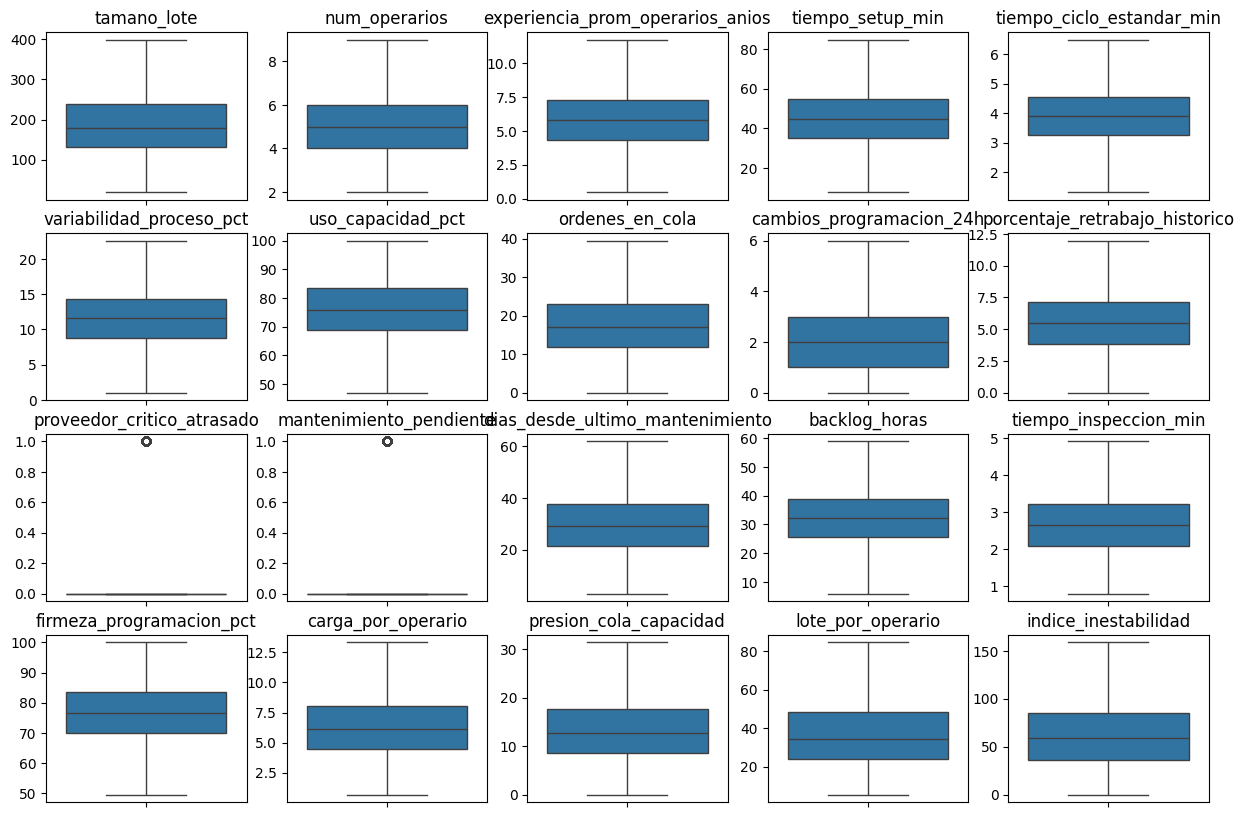

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionamos algunas columnas numéricas para visualizar
numeric_cols = df_train.select_dtypes(include=np.number).columns.tolist()

# Excluimos 'entrega_tardia' ya que es la variable objetivo binaria
if 'entrega_tardia' in numeric_cols:
    numeric_cols.remove('entrega_tardia')

# Creamos boxplots para visualizar los atípicos en df_train
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 5, i + 1) # Ajusta el tamaño de la cuadrícula según el número de columnas
    sns.boxplot(y=df_train[col])
    plt.title(col)
    plt.ylabel('')
plt.tight_layout()
plt.suptitle('Boxplots de Columnas Numéricas en df_train para Identificación de Atípicos', y=1.02, fontsize=16)
plt.show()

# Esto es un comentario para mantener el flujo.
# Una vez visualizados los posibles valores atípicos, podemos decidir la estrategia a seguir: eliminar, reemplazar por un umbral (capping) o transformaciones (ej. logarítmicas) para reducir su impacto. ¿Hay alguna columna en particular donde te gustaría aplicar un tratamiento específico para los atípicos?

### Ingeniería de Variables

Con el fin de mejorar la capacidad predictiva de los modelos, se implementa un proceso de ingeniería de variables orientado a capturar de manera más precisa la dinámica operativa del sistema productivo.

Las variables originales, aunque relevantes, no siempre reflejan adecuadamente fenómenos como la sobrecarga de trabajo, la congestión del sistema, la inestabilidad de los procesos o los riesgos operativos asociados al mantenimiento y a factores externos. Por esta razón, se construyen nuevas variables derivadas que integran múltiples dimensiones del proceso productivo.

Estas transformaciones se realizan sobre los datos previamente imputados y antes del proceso de escalado, con el objetivo de mantener la coherencia en el flujo de preprocesamiento. Además, se prioriza que cada variable tenga una interpretación clara desde la perspectiva de la ingeniería industrial, evitando la generación de transformaciones arbitrarias.

A continuación, se presentan las variables derivadas construidas.

In [24]:
# =============================================================================
# INGENIERÍA DE VARIABLES
# =============================================================================

# ── IMPORTANTE: trabajamos sobre df_train y df_test ya imputados ─────────────

def crear_variables_derivadas(df):
    """
    Crea 6 variables derivadas con justificación industrial.
    Debe aplicarse sobre datos ya imputados, antes de escalar.
    """
    df = df.copy()

    # V1 — carga_por_operario
    # Idea: el backlog en horas dividido por el número de operarios mide
    # la presión real sobre cada persona del equipo. Alta carga individual
    # → mayor probabilidad de retraso.
    # Los modelos lineales no pueden dividir dos columnas por sí solos.
    df['carga_por_operario'] = df['backlog_horas'] / df['num_operarios']

    # V2 — presion_cola_capacidad
    # Idea: una cola larga solo es crítica cuando la capacidad ya está
    # saturada. El producto captura el cuello de botella: ambas condiciones
    # simultáneas colapsan el sistema.
    df['presion_cola_capacidad'] = df['ordenes_en_cola'] * (df['uso_capacidad_pct'] / 100)

    # V3 — lote_por_operario
    # Idea: un lote grande con poca dotación genera sobrecarga que
    # tamano_lote por sí solo no captura. Correlación de tamano_lote
    # con target era solo -0.026; esta versión mejora esa señal.
    df['lote_por_operario'] = df['tamano_lote'] / df['num_operarios']

    # V4 — indice_inestabilidad
    # Idea: un proceso variable que además genera retrabajo acumula
    # tiempo no planeado desde dos fuentes distintas. Su producto
    # captura ese efecto compuesto mejor que cada variable por separado.
    df['indice_inestabilidad'] = (df['variabilidad_proceso_pct'] *
                                  df['porcentaje_retrabajo_historico'])

    # V5 — riesgo_externo
    # Idea: suma los shocks externos activos (proveedor atrasado +
    # mantenimiento pendiente). Cuando ambos coinciden el riesgo
    # se amplifica operativamente, no se suma linealmente.
    df['riesgo_externo'] = (df['proveedor_critico_atrasado'] +
                            df['mantenimiento_pendiente'])

    # V6 — degradacion_equipo
    # Idea: el mantenimiento pendiente es más peligroso cuantos más
    # días lleva sin ejecutarse. La multiplicación activa esta variable
    # SOLO cuando hay mantenimiento pendiente, y escala con los días de atraso.
    df['degradacion_equipo'] = (df['mantenimiento_pendiente'] *
                                df['dias_desde_ultimo_mantenimiento'])

    return df


# Aplicar a ambos conjuntos
df_train = crear_variables_derivadas(df_train)
df_test  = crear_variables_derivadas(df_test)

# Verificar que se crearon correctamente
nuevas = ['carga_por_operario', 'presion_cola_capacidad', 'lote_por_operario',
          'indice_inestabilidad', 'riesgo_externo', 'degradacion_equipo']

print("Variables derivadas creadas:")
print(df_train[nuevas].describe().round(3))
print(f"\nNulos en variables nuevas (train): {df_train[nuevas].isnull().sum().sum()}")

Variables derivadas creadas:
       carga_por_operario  presion_cola_capacidad  lote_por_operario  \
count            1800.000                1800.000           1800.000   
mean                6.698                  13.398             39.469   
std                 3.349                   6.460             22.809   
min                 0.858                   0.000              5.667   
25%                 4.500                   8.590             24.000   
50%                 6.108                  12.738             34.388   
75%                 8.035                  17.706             48.250   
max                26.100                  39.500            176.000   

       indice_inestabilidad  riesgo_externo  degradacion_equipo  
count              1800.000        1800.000            1800.000  
mean                 63.666           0.386               7.966  
std                  38.588           0.560              15.941  
min                   0.000           0.000               

### Análisis e interpretación de las variables derivadas

Las variables construidas permiten enriquecer significativamente la representación del sistema productivo, incorporando relaciones e interacciones que no son evidentes en las variables originales.

En primer lugar, las variables asociadas a la carga operativa, como *carga_por_operario* y *lote_por_operario*, permiten capturar la presión real sobre los recursos humanos. Estas transformaciones son relevantes debido a que el impacto del volumen de trabajo depende directamente de la cantidad de operarios disponibles, lo que influye en la probabilidad de retrasos.

Por su parte, la variable *presion_cola_capacidad* introduce una medida de congestión del sistema al combinar la acumulación de órdenes con el nivel de utilización de la capacidad. Esta interacción resulta clave para identificar cuellos de botella, los cuales son una de las principales causas de incumplimiento en entornos productivos.

En términos de estabilidad del proceso, la variable *indice_inestabilidad* integra la variabilidad del proceso con el retrabajo histórico, permitiendo aproximar el tiempo no planificado derivado de ineficiencias operativas. Este tipo de comportamiento suele tener un impacto directo en los tiempos de entrega.

Adicionalmente, la variable *riesgo_externo* permite identificar escenarios en los que la operación se ve afectada por factores externos, como atrasos de proveedores o mantenimiento pendiente. La presencia simultánea de estos eventos incrementa el riesgo operativo de manera significativa.

Finalmente, la variable *degradacion_equipo* captura el efecto acumulativo del mantenimiento no realizado, considerando el tiempo transcurrido desde la última intervención. Esta variable es especialmente relevante en contextos donde la confiabilidad de los equipos es un factor crítico para el cumplimiento de los tiempos de producción.

En conjunto, estas variables permiten representar de manera más completa la complejidad del sistema productivo, lo que se espera se traduzca en una mejora en el desempeño de los modelos de clasificación.

### Verificación de la relevancia de las variables derivadas

Una vez construidas las variables derivadas, se procede a evaluar su relación con la variable objetivo *entrega_tardia*. Este análisis tiene como propósito validar si las nuevas variables aportan información relevante para la predicción del retraso en las órdenes de producción.

Para ello, se calcula el coeficiente de correlación de Pearson entre cada variable (tanto original como derivada) y la variable objetivo. Aunque la correlación lineal no captura todas las relaciones posibles, sí permite obtener una primera aproximación sobre la capacidad explicativa de cada variable de forma individual.

Adicionalmente, se realiza una comparación directa entre las variables originales más relevantes y las nuevas variables construidas, con el fin de identificar si la ingeniería de variables logra mejorar la señal predictiva presente en los datos.

Los resultados se presentan tanto de forma gráfica como tabular para facilitar su interpretación.

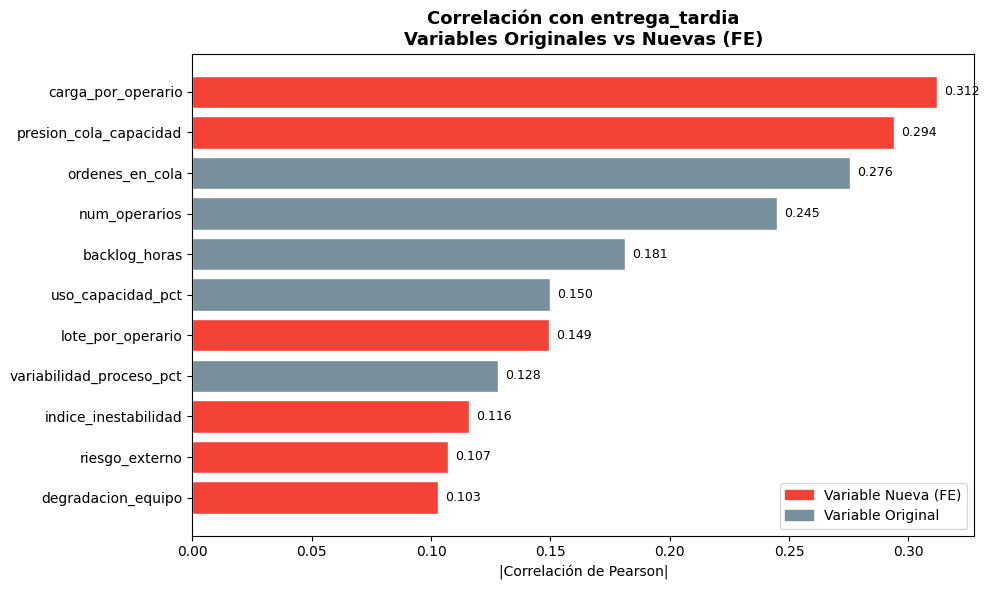


=== CORRELACIONES CON entrega_tardia ===
carga_por_operario          0.3120
presion_cola_capacidad      0.2938
ordenes_en_cola             0.2756
num_operarios              -0.2451
backlog_horas               0.1812
uso_capacidad_pct           0.1497
lote_por_operario           0.1493
variabilidad_proceso_pct    0.1279
indice_inestabilidad        0.1158
riesgo_externo              0.1069
degradacion_equipo          0.1029

Mejor variable original (ordenes_en_cola): ~0.276
Variables que la superan están marcadas con ←
  ✓ presion_cola_capacidad: 0.2938 ← SUPERA la mejor variable original
  ✓ carga_por_operario: 0.3120 ← SUPERA la mejor variable original


In [25]:
# =============================================================================
# VERIFICACIÓN: correlación de variables nuevas con el target
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

nuevas = ['carga_por_operario', 'presion_cola_capacidad', 'lote_por_operario',
          'indice_inestabilidad', 'riesgo_externo', 'degradacion_equipo']

originales_top = ['ordenes_en_cola', 'num_operarios', 'backlog_horas',
                  'uso_capacidad_pct', 'variabilidad_proceso_pct']

# Calculamos sobre df_train ANTES del clipping/encoding (datos aún originales)
todas_vars = originales_top + nuevas
corrs = df_train[todas_vars + ['entrega_tardia']].corr()['entrega_tardia'].drop('entrega_tardia')
corrs = corrs.reindex(todas_vars).sort_values(key=abs, ascending=True)

colores = ['#F44336' if v in nuevas else '#78909C' for v in corrs.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(corrs.index, corrs.abs(), color=colores, edgecolor='white')
ax.set_title('Correlación con entrega_tardia\nVariables Originales vs Nuevas (FE)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('|Correlación de Pearson|')

for bar, v in zip(bars, corrs.abs()):
    ax.text(v + 0.003, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=9)

leyenda = [mpatches.Patch(color='#F44336', label='Variable Nueva (FE)'),
           mpatches.Patch(color='#78909C', label='Variable Original')]
ax.legend(handles=leyenda, fontsize=10)
plt.tight_layout()
plt.show()

# Mostrar tabla de correlaciones
print("\n=== CORRELACIONES CON entrega_tardia ===")
print(corrs.sort_values(key=abs, ascending=False).round(4).to_string())
print("\nMejor variable original (ordenes_en_cola): ~0.276")
print("Variables que la superan están marcadas con ←")
for v, c in corrs.items():
    if abs(c) > 0.276:
        print(f"  ✓ {v}: {c:.4f} ← SUPERA la mejor variable original")

### Análisis de resultados

El análisis de correlación evidencia que las variables derivadas logran capturar relaciones más fuertes con la variable objetivo en comparación con varias de las variables originales. Este resultado sugiere que la ingeniería de variables permitió representar de manera más efectiva ciertos fenómenos operativos que no eran evidentes de forma directa en los datos iniciales.

En particular, se observa que algunas de las variables construidas superan en magnitud de correlación a las variables originales más relevantes, como *ordenes_en_cola*. Esto indica que las transformaciones realizadas no solo combinan información existente, sino que generan nuevas señales predictivas que pueden ser aprovechadas por los modelos.

Desde una perspectiva operativa, estos resultados refuerzan la importancia de considerar interacciones entre variables. Por ejemplo, la combinación de carga de trabajo, utilización de capacidad y disponibilidad de recursos permite identificar condiciones de congestión y sobrecarga que son determinantes en la ocurrencia de retrasos.

Asimismo, variables asociadas a la inestabilidad del proceso y al estado de los equipos muestran una relación relevante con el retraso, lo que evidencia que factores como la variabilidad, el retrabajo y el mantenimiento tienen un impacto directo en el desempeño del sistema productivo.

En conjunto, este análisis valida que las variables derivadas aportan información adicional significativa, lo que justifica su inclusión en la etapa de modelado y respalda la hipótesis de que una adecuada ingeniería de variables puede mejorar el desempeño de modelos de clasificación relativamente simples.

### Tecnica Utilizada (Clipping)


Se aplicó un tratamiento de valores atípicos mediante el método de rango intercuartílico (IQR), recortando los valores extremos a límites superiores e inferiores. Este enfoque permite reducir el impacto de los outliers sin eliminar observaciones del dataset.

Variables numéricas continuas:
['tamano_lote', 'num_operarios', 'experiencia_prom_operarios_anios', 'tiempo_setup_min', 'tiempo_ciclo_estandar_min', 'variabilidad_proceso_pct', 'uso_capacidad_pct', 'ordenes_en_cola', 'cambios_programacion_24h', 'porcentaje_retrabajo_historico', 'dias_desde_ultimo_mantenimiento', 'backlog_horas', 'tiempo_inspeccion_min', 'firmeza_programacion_pct', 'carga_por_operario', 'presion_cola_capacidad', 'lote_por_operario', 'indice_inestabilidad', 'riesgo_externo', 'degradacion_equipo']


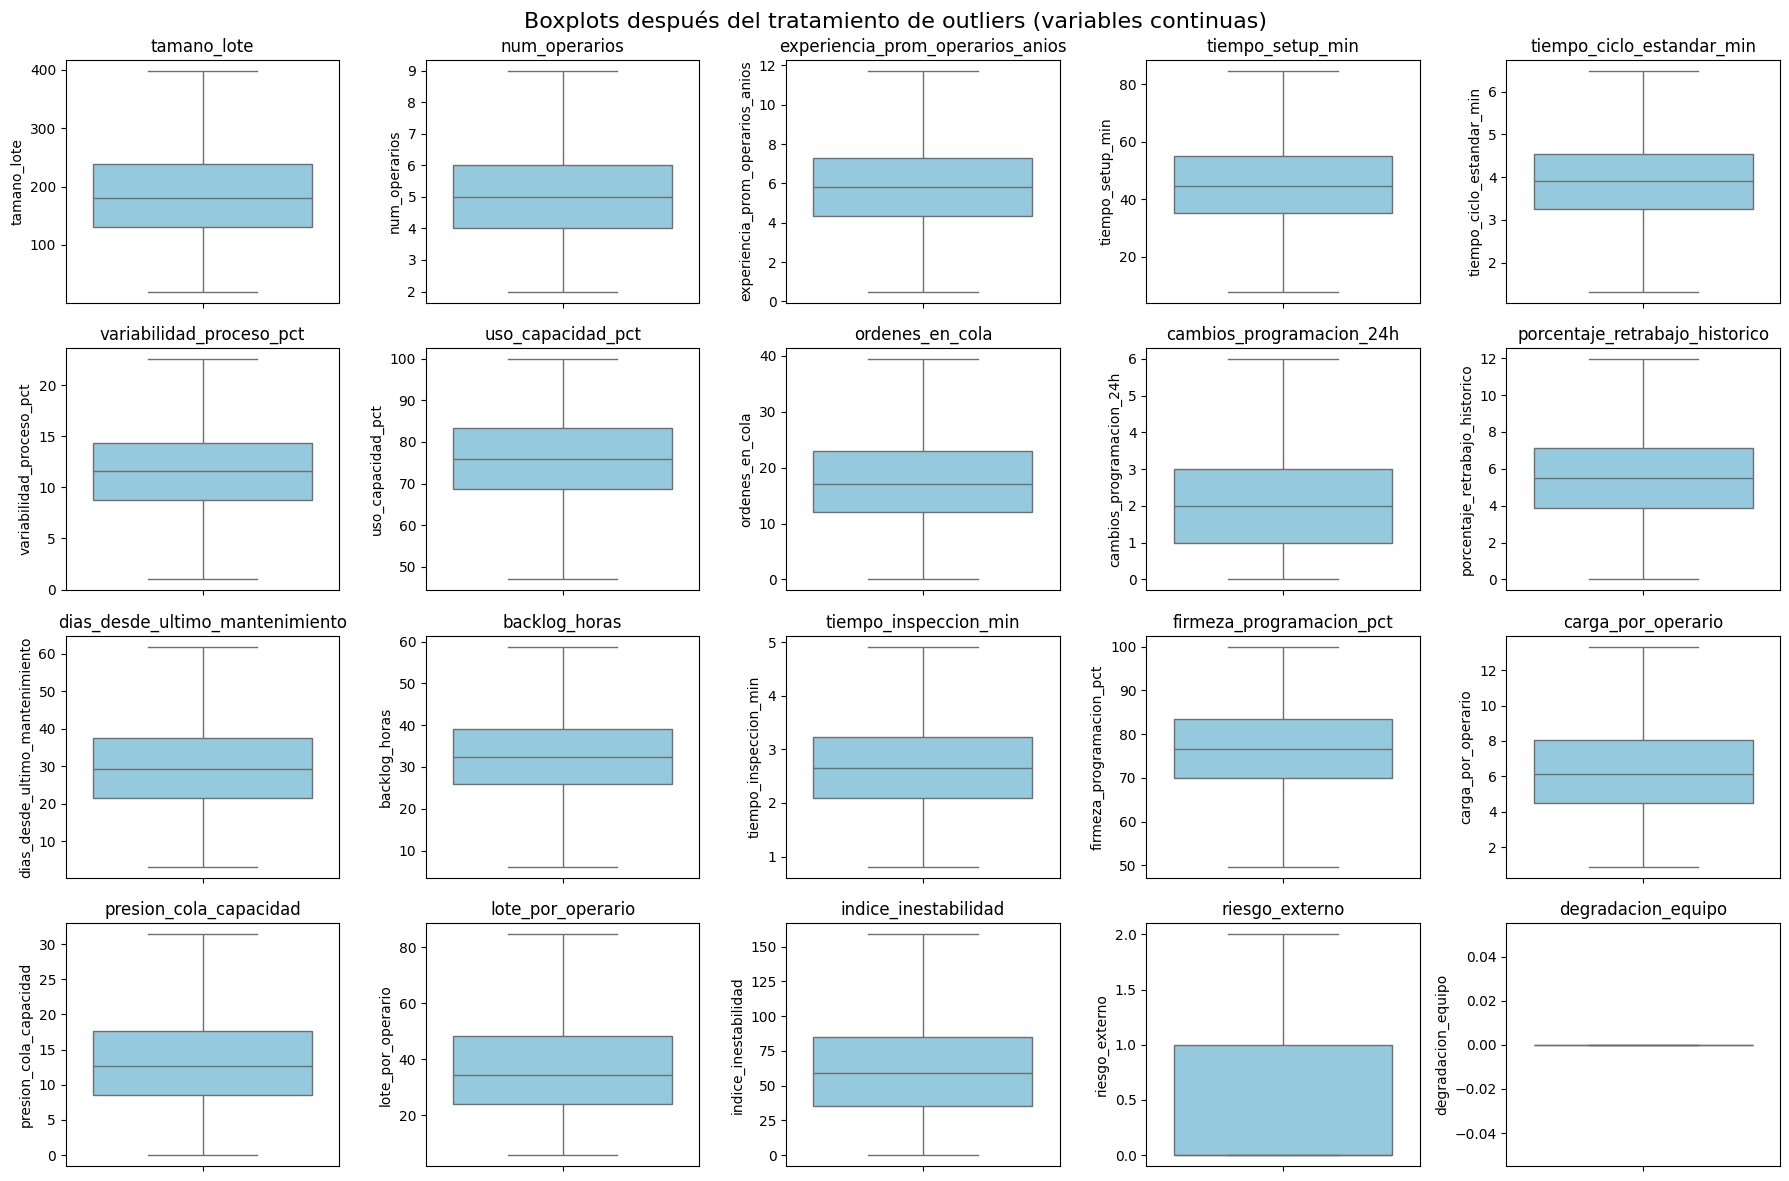

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# ==============================
# 1. Seleccionar variables numéricas continuas
# ==============================

num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Quitar target si existe
if "entrega_tardia" in num_cols:
    num_cols.remove("entrega_tardia")

# Filtrar solo variables continuas (excluir binarias y one-hot)
num_cont_cols = [col for col in num_cols if df_train[col].nunique() > 2]

print("Variables numéricas continuas:")
print(num_cont_cols)

# ==============================
# 2. Función para tratar outliers con IQR
# ==============================

def cap_outliers(df, columns):
    df_copy = df.copy()
    limites = {}

    for col in columns:
        Q1 = df_copy[col].quantile(0.25)
        Q3 = df_copy[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_copy[col] = df_copy[col].clip(lower, upper)
        limites[col] = (lower, upper)

    return df_copy, limites

# ==============================
# 3. Aplicar en TRAIN
# ==============================

df_train, limites_outliers = cap_outliers(df_train, num_cont_cols)

# ==============================
# 4. Aplicar en TEST (mismos límites)
# ==============================

df_test = df_test.copy()

for col in num_cont_cols:
    lower, upper = limites_outliers[col]
    df_test[col] = df_test[col].clip(lower, upper)

# ==============================
# 5. Graficar boxplots (solo continuas)
# ==============================

n = len(num_cont_cols)
cols = 5
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cont_cols):
    sns.boxplot(y=df_train[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col)

# Eliminar espacios vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots después del tratamiento de outliers (variables continuas)", fontsize=16)
plt.tight_layout()
plt.show()

### Integración de variables derivadas en el preprocesamiento

Con el fin de evaluar el impacto de la ingeniería de variables sobre el desempeño de los modelos, se construye un pipeline de preprocesamiento paralelo que incorpora las variables derivadas previamente definidas.

Este enfoque permite realizar una comparación directa entre el modelo base (sin ingeniería de variables) y el modelo enriquecido (con variables derivadas), garantizando que ambas versiones sean entrenadas bajo las mismas condiciones. De esta manera, cualquier mejora observada en el desempeño puede atribuirse de forma consistente a la incorporación de nuevas variables.

El proceso de preprocesamiento mantiene la misma lógica aplicada en el pipeline original, incluyendo el tratamiento de valores atípicos mediante clipping basado en el rango intercuartílico (IQR), la transformación de variables categóricas mediante codificación one-hot y la estandarización de variables numéricas.

Adicionalmente, se asegura que todas las transformaciones sean aprendidas exclusivamente a partir del conjunto de entrenamiento y posteriormente aplicadas a los conjuntos de validación y prueba, evitando así posibles fugas de información.

Finalmente, se realiza una partición estratificada de los datos, preservando la proporción de la variable objetivo, lo cual resulta fundamental en problemas de clasificación binaria.

In [27]:
# =============================================================================
# PREPROCESAMIENTO CON FE
# =============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# ── Paso 1: partir del df_train con variables derivadas ya creadas ───────────

# Variables nuevas que se incluyeron
nuevas_fe = ['carga_por_operario', 'presion_cola_capacidad', 'lote_por_operario',
             'indice_inestabilidad', 'riesgo_externo', 'degradacion_equipo']

# ── Paso 2: clipping de outliers──────────────
# INCLUYE las variables nuevas en el clipping

def cap_outliers_fe(df_tr, df_te, cols):
    """Aplica IQR clipping aprendido en train, aplicado en test."""
    df_tr = df_tr.copy()
    df_te = df_te.copy()
    limites = {}
    for col in cols:
        Q1 = df_tr[col].quantile(0.25)
        Q3 = df_tr[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_tr[col] = df_tr[col].clip(lower, upper)
        df_te[col] = df_te[col].clip(lower, upper)
        limites[col] = (lower, upper)
    return df_tr, df_te, limites

# Columnas numéricas continuas para clipping (originales + nuevas)
num_cols_fe = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'entrega_tardia' in num_cols_fe:
    num_cols_fe.remove('entrega_tardia')
num_cont_cols_fe = [col for col in num_cols_fe if df_train[col].nunique() > 2]

df_train_fe, df_test_fe, _ = cap_outliers_fe(df_train, df_test, num_cont_cols_fe)

# ── Paso 3: One-Hot Encoding  ────────────────────────
categorical_cols = df_train_fe.select_dtypes(include='object').columns.tolist()
if 'id_orden' in categorical_cols:
    categorical_cols.remove('id_orden')

df_train_fe = pd.get_dummies(df_train_fe, columns=categorical_cols, drop_first=True, dtype=int)
df_test_fe  = pd.get_dummies(df_test_fe,  columns=categorical_cols, drop_first=True, dtype=int)

# Alinear columnas train/test
for col in set(df_train_fe.columns) - set(df_test_fe.columns):
    df_test_fe[col] = 0
for col in set(df_test_fe.columns) - set(df_train_fe.columns):
    df_train_fe[col] = 0
# Alinear columnas: test solo tiene columnas que no son el target
cols_sin_target = [c for c in df_train_fe.columns if c not in ['entrega_tardia']]
for col in set(cols_sin_target) - set(df_test_fe.columns):
    df_test_fe[col] = 0
df_test_fe = df_test_fe[cols_sin_target]

# ── Paso 4: separar X e y ────────────────────────────────────────────────────
X_fe = df_train_fe.drop(['entrega_tardia', 'id_orden'], axis=1, errors='ignore')
y_fe = df_train_fe['entrega_tardia']
X_test_fe_final = df_test_fe.drop(['id_orden'], axis=1, errors='ignore')  # test no tiene entrega_tardia

# ── Paso 5: mismo split estratificado que usas en los modelos base ───────────
X_train_fe_split, X_val_fe, y_train_fe_split, y_val_fe = train_test_split(
    X_fe, y_fe,
    test_size=0.20,
    random_state=42,
    stratify=y_fe
)

# ── Paso 6: escalado (StandardScaler aprendido en train, aplicado en val) ────
scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe_split)
X_val_fe_scaled   = scaler_fe.transform(X_val_fe)
X_test_fe_scaled  = scaler_fe.transform(X_test_fe_final)

print(f"X_train FE: {X_train_fe_scaled.shape}")
print(f"X_val   FE: {X_val_fe_scaled.shape}")
print(f"Variables originales base : {X_train.shape[1]}")
print(f"Variables con FE          : {X_train_fe_scaled.shape[1]}")
print(f"Variables nuevas agregadas: {X_train_fe_scaled.shape[1] - X_train.shape[1]}")

X_train FE: (1440, 32)
X_val   FE: (360, 32)
Variables originales base : 26
Variables con FE          : 32
Variables nuevas agregadas: 6


### Análisis del preprocesamiento con variables derivadas

El pipeline construido permite integrar de manera consistente las variables derivadas dentro del flujo de preparación de datos, garantizando su compatibilidad con los modelos de aprendizaje automático utilizados en el proyecto.

En primer lugar, el tratamiento de valores atípicos mediante clipping asegura que tanto las variables originales como las derivadas mantengan rangos coherentes, evitando que valores extremos distorsionen el proceso de entrenamiento. Este paso resulta especialmente relevante en variables construidas como razones o productos, las cuales pueden amplificar la presencia de outliers.

Posteriormente, la aplicación de codificación one-hot sobre las variables categóricas permite transformar la información cualitativa en un formato numérico adecuado para modelos lineales, manteniendo la interpretabilidad de las variables.

El escalado mediante estandarización garantiza que todas las variables, independientemente de su escala original, contribuyan de manera equilibrada al modelo. Este aspecto es fundamental en algoritmos como la regresión logística, el perceptrón y Adaline, los cuales son sensibles a la magnitud de las variables.

Adicionalmente, la construcción de este pipeline paralelo permite cuantificar de manera directa el incremento en la dimensionalidad del conjunto de datos como resultado de la ingeniería de variables. Este aumento no solo refleja la incorporación de nuevas variables, sino también una representación más rica de las relaciones presentes en el sistema productivo.

En conjunto, este preprocesamiento establece una base sólida para la etapa de modelado, permitiendo evaluar de forma rigurosa el impacto de las variables derivadas en la capacidad predictiva de los modelos.

### 3.4 Tratamiento de Variables Categóricas (One-Hot Encoding)

Convertiremos las variables categóricas a un formato numérico utilizando One-Hot Encoding. Esto es necesario para que la mayoría de los algoritmos de Machine Learning puedan procesar estos datos.

In [28]:
import pandas as pd
# Identificar columnas categóricas (excluyendo 'id_orden')
categorical_cols = df_train.select_dtypes(include='object').columns.tolist()
if 'id_orden' in categorical_cols:
    categorical_cols.remove('id_orden')

print(f"Columnas categóricas identificadas para encoding: {categorical_cols}")

# Aplicar One-Hot Encoding a df_train
df_train_encoded = pd.get_dummies(df_train, columns=categorical_cols, drop_first=True, dtype=int)

# Aplicar One-Hot Encoding a df_test
df_test_encoded = pd.get_dummies(df_test, columns=categorical_cols, drop_first=True, dtype=int)

# Alinear columnas entre df_train_encoded y df_test_encoded
# Esto es crucial para asegurar que ambos datasets tengan el mismo número y orden de columnas
train_cols = set(df_train_encoded.columns)
test_cols = set(df_test_encoded.columns)

missing_in_test = list(train_cols - test_cols)
for col in missing_in_test:
    df_test_encoded[col] = 0

missing_in_train = list(test_cols - train_cols)
for col in missing_in_train:
    df_train_encoded[col] = 0

df_test_encoded = df_test_encoded[df_train_encoded.columns] # Asegurar el mismo orden de columnas

print(f"\nDimensiones de df_train después del One-Hot Encoding: {df_train_encoded.shape}")
print(f"Dimensiones de df_test después del One-Hot Encoding: {df_test_encoded.shape}")

print("\nPrimeras 5 filas de df_train_encoded:")
print(df_train_encoded.head())

print("\nPrimeras 5 filas de df_test_encoded:")
print(df_test_encoded.head())

# Guardamos una copia SIN las variables FE para la línea base
# Esto garantiza que la comparación base vs FE sea justa:
# los modelos base no ven las variables derivadas
cols_fe_nuevas = ['carga_por_operario', 'presion_cola_capacidad', 'lote_por_operario',
                  'indice_inestabilidad', 'riesgo_externo', 'degradacion_equipo']
cols_base_only = [c for c in df_train_encoded.columns
                  if c not in cols_fe_nuevas]
df_train_base_encoded = df_train_encoded[cols_base_only].copy()
df_test_base_encoded  = df_test_encoded[[c for c in cols_base_only
                         if c != 'entrega_tardia']].copy()

df_train = df_train_encoded
df_test = df_test_encoded

Columnas categóricas identificadas para encoding: ['familia_producto', 'turno', 'nivel_automatizacion', 'prioridad']

Dimensiones de df_train después del One-Hot Encoding: (1800, 34)
Dimensiones de df_test después del One-Hot Encoding: (600, 34)

Primeras 5 filas de df_train_encoded:
   id_orden  tamano_lote  num_operarios  experiencia_prom_operarios_anios  \
0  OP-00650        195.0              3                              4.82   
1  OP-01233        398.5              4                              3.18   
2  OP-00518        216.0              4                              5.59   
3  OP-01421        173.0              4                              8.84   
4  OP-01044        193.0              2                              3.60   

   tiempo_setup_min  tiempo_ciclo_estandar_min  variabilidad_proceso_pct  \
0              37.7                       3.98                     13.46   
1              38.5                       4.55                      6.60   
2              39.0     

### 3.5 Escalado de Características Numéricas

Aplicaremos escalado a las características numéricas para que todas contribuyan de manera equitativa al modelo, especialmente importante para algoritmos basados en distancia o gradiente.

### 3.6 Colinealidad y redundancia
Se calculó la matriz de correlación entre variables numéricas con el fin de identificar posibles relaciones lineales fuertes que pudieran indicar colinealidad o redundancia entre variables.



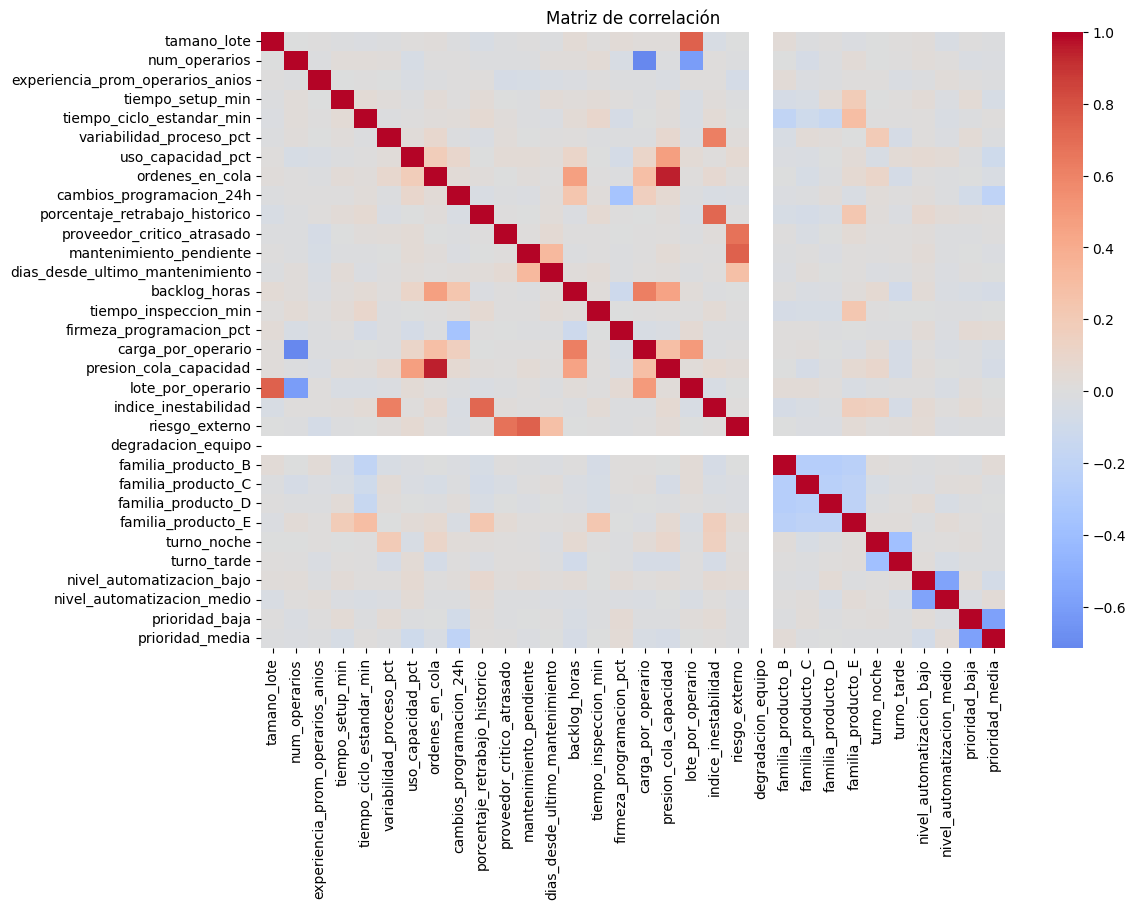

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo variables numéricas (sin target)
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove("entrega_tardia")

# Matriz de correlación
corr_matrix = df_train[num_cols].corr()

# Visualización
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

In [30]:
import numpy as np

# Detectar correlaciones altas
threshold = 0.8
high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) >= threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            high_corr.append((col1, col2, corr_matrix.iloc[i, j]))

high_corr

[('presion_cola_capacidad', 'ordenes_en_cola', np.float64(0.942968174339014))]

Ninguna de las variables está altamente correlacionada con otra. Las variables que más tienen indicios de estar correlacionadas entre ellas son:

- ordenes_en_cola --> backlog_horas: Con un índice de correlación de 0.4, se

### **4. Análisis Exploratorio de Datos EDA**

**4.1 Proporción de la clase objetivo**

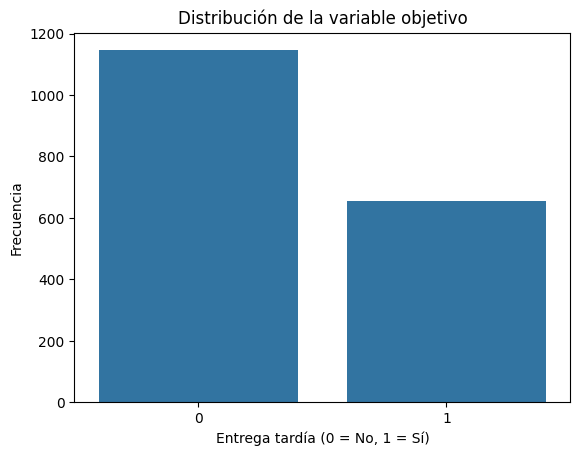

,count
entrega_tardia,
0,0.636667
1,0.363333


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Conteo
target_counts = df_train["entrega_tardia"].value_counts()

# Gráfico
sns.countplot(x="entrega_tardia", data=df_train)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Entrega tardía (0 = No, 1 = Sí)")
plt.ylabel("Frecuencia")
plt.show()

# Proporciones
target_counts / len(df_train)

Se analizó la distribución de la variable objetivo entrega_tardia, observándose la proporción de órdenes entregadas a tiempo frente a aquellas con retraso. Este análisis permite identificar si existe desbalance de clases, lo cual puede influir en el desempeño de los modelos de clasificación.

**4.2 Distribución de variables (UNIVARIADO)**

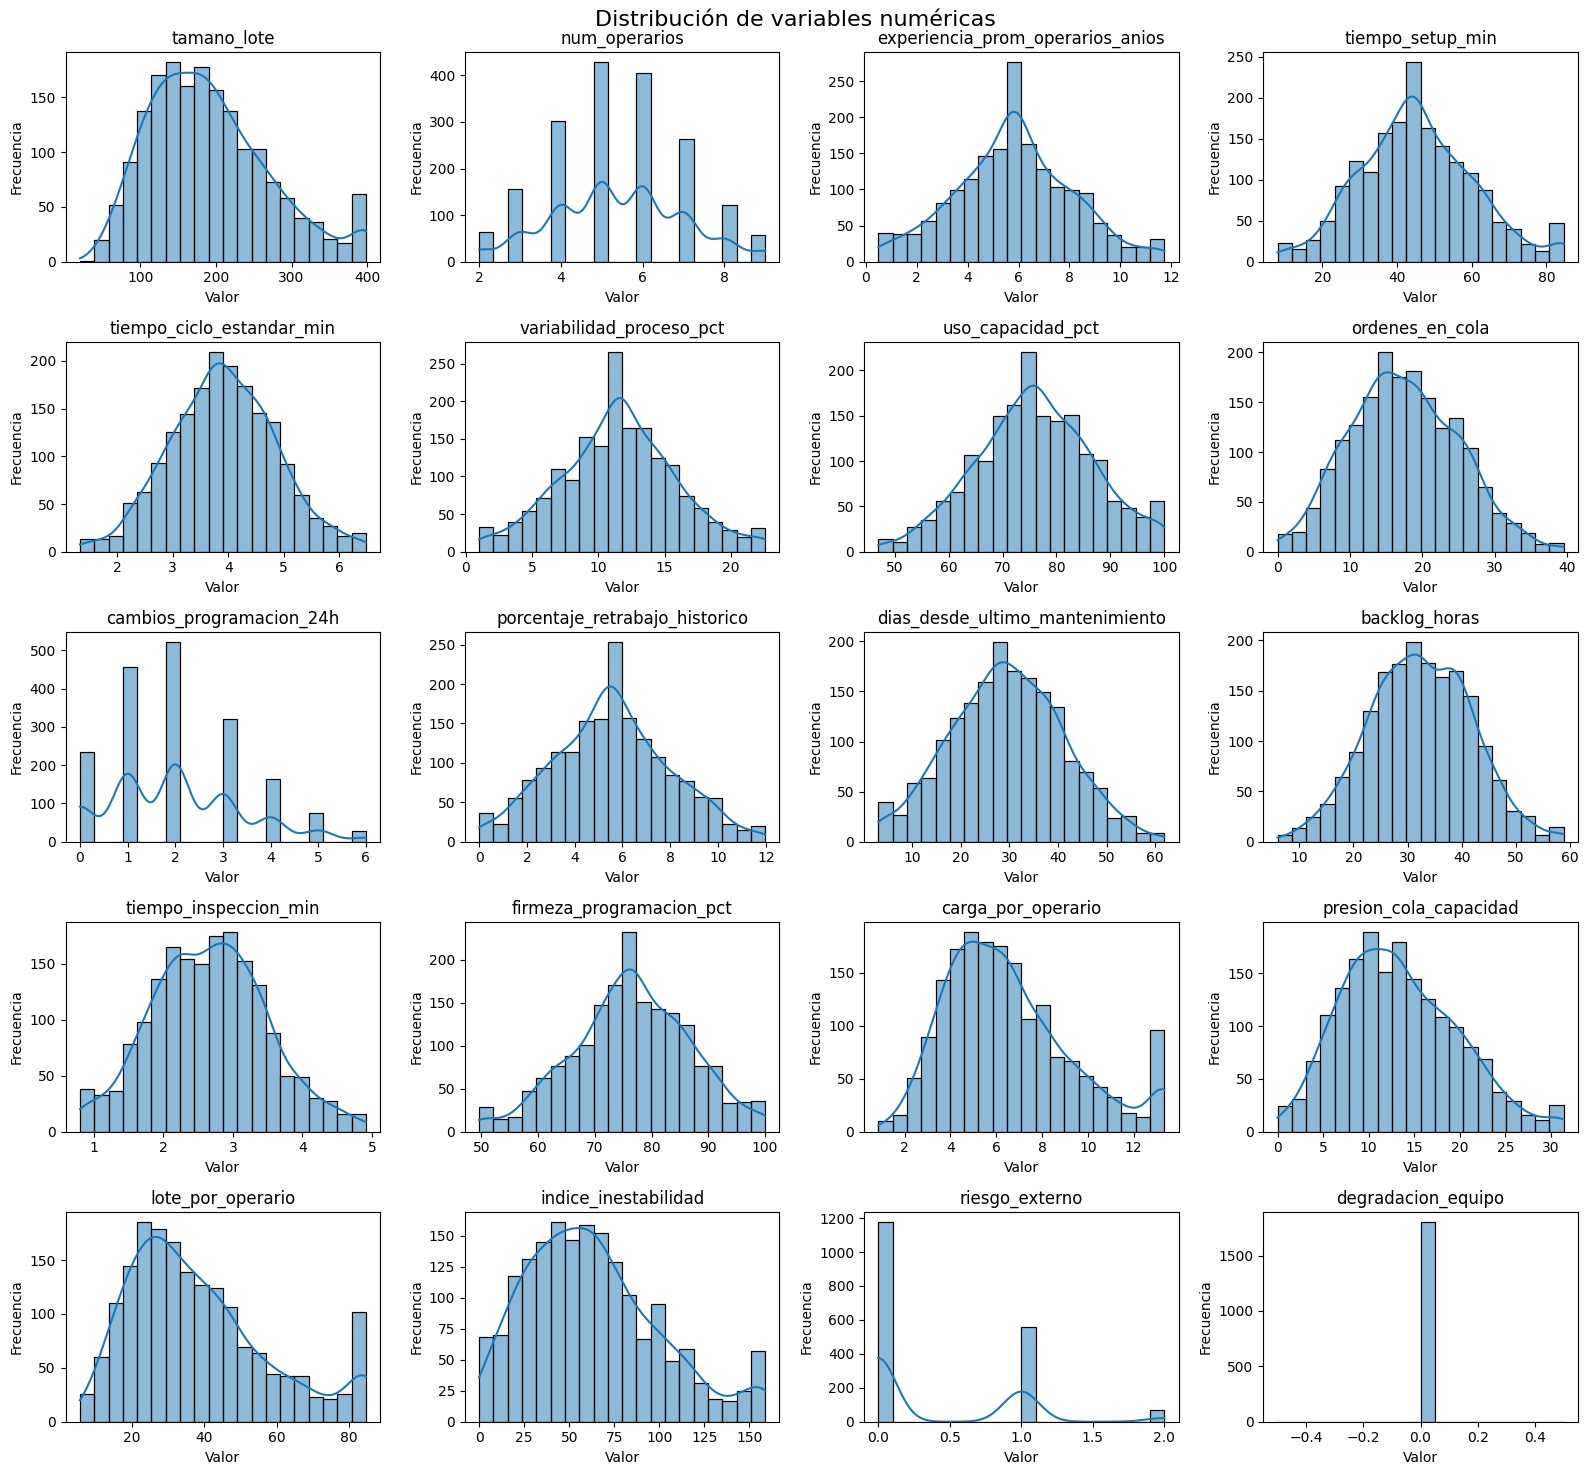

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

cols = 4
rows = math.ceil(len(num_cont_cols)/cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, rows*3))
axes = axes.flatten()

for i, col in enumerate(num_cont_cols):
    sns.histplot(df_train[col], bins=20, ax=axes[i], kde=True)
    axes[i].set_title(col)
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frecuencia")

# Eliminar espacios vacíos
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribución de variables numéricas", fontsize=16)
plt.tight_layout()
plt.show()

Se analizaron las distribuciones de las variables numéricas mediante histogramas, identificando la forma de sus distribuciones, posibles sesgos y rangos de variación. Esto permitió comprender el comportamiento individual de cada variable dentro del sistema productivo.

Entonces, como se puede ver en cada gráfico, la distribución de cada variable es **normal**.

4.3 **RELACIÓN NUMÉRICAS vs VARIABLE OBJETIVO (CLAVE)**

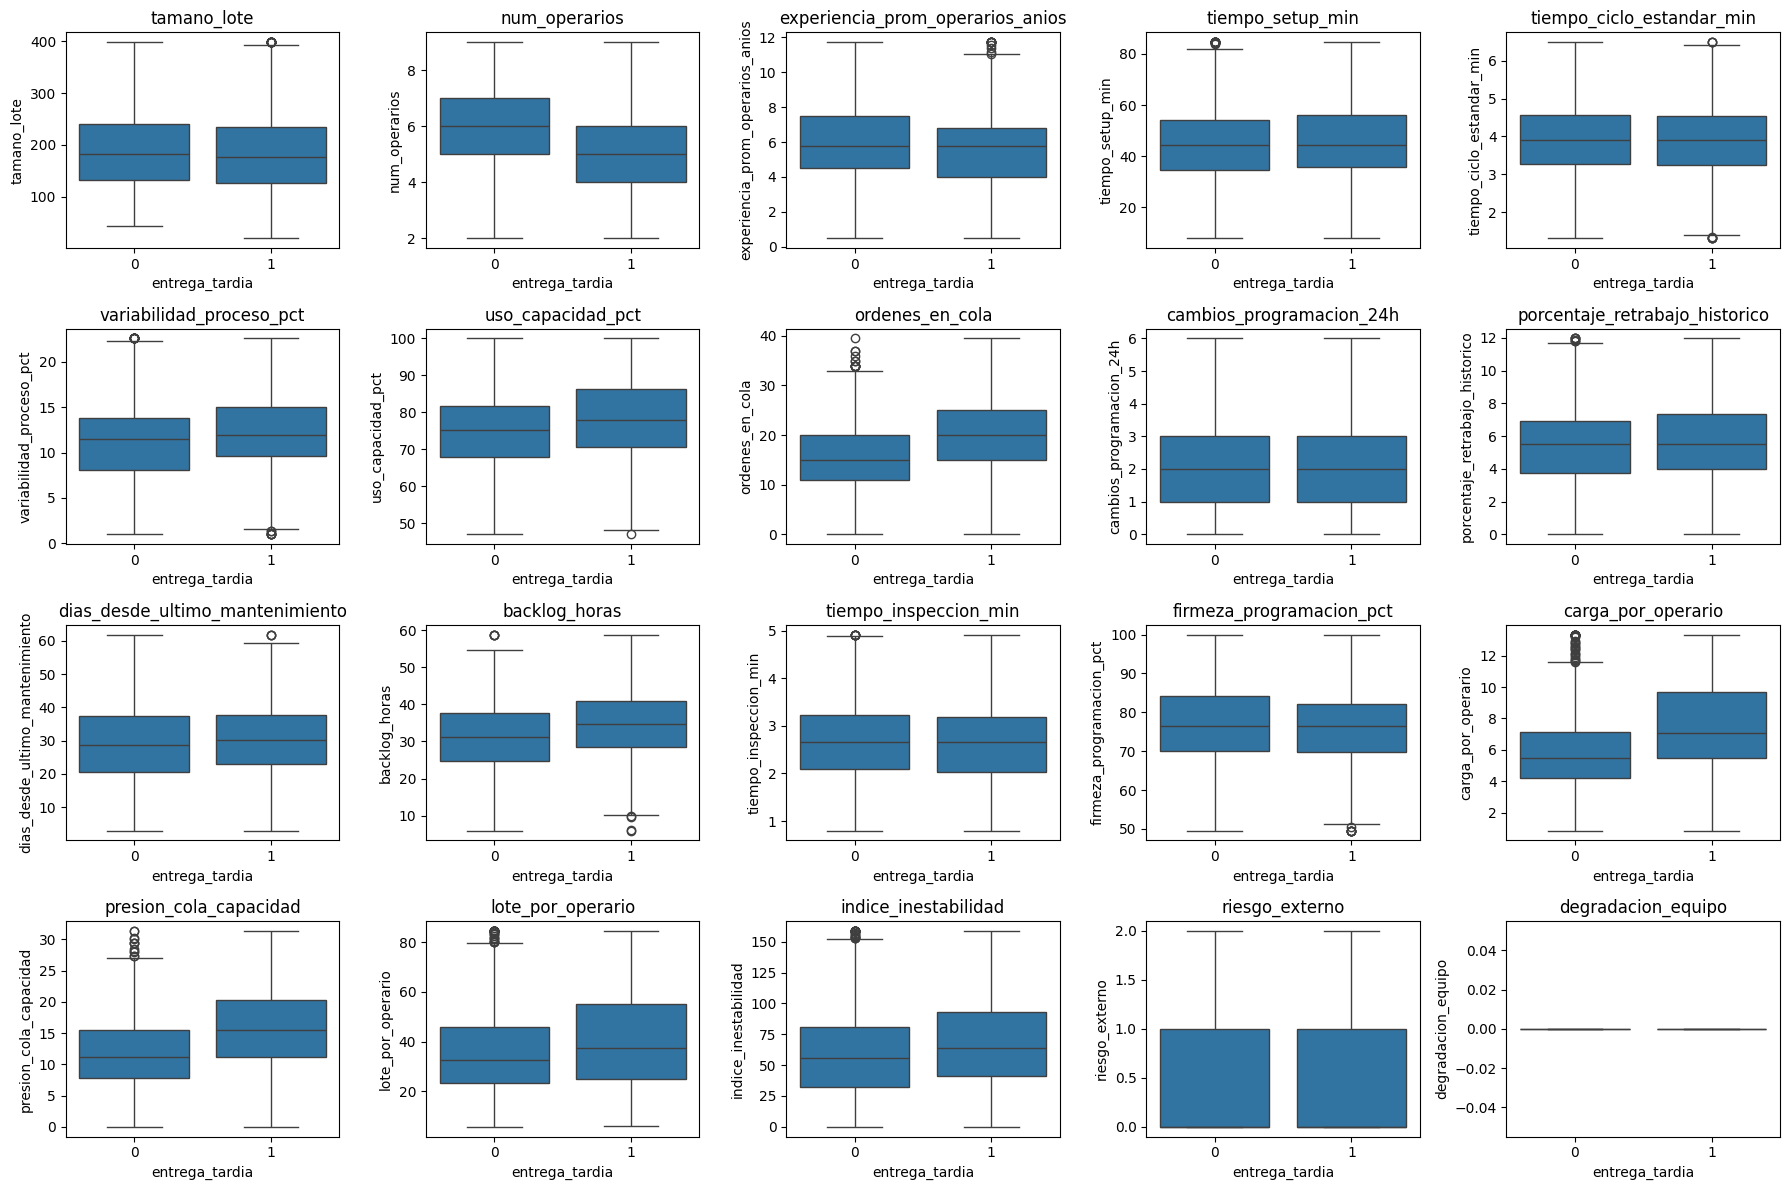

In [33]:
import math

cols = 5
rows = math.ceil(len(num_cont_cols)/cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows*3))
axes = axes.flatten()

for i, col in enumerate(num_cont_cols):
    sns.boxplot(x="entrega_tardia", y=col, data=df_train, ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Se analizaron las relaciones entre variables numéricas y la variable objetivo mediante boxplots segmentados por clase. Este análisis permitió identificar diferencias en la distribución de las variables entre órdenes con y sin retraso, evidenciando posibles factores asociados al incumplimiento en las entregas.

**4.4 RELACIÓN CATEGÓRICAS vs VARIABLE OBJETIVO**

### IMPORTANTE

**df_train_original   para EDA**

**df_train            para modelado**

In [34]:
# utilizamos la base de datos original para ver las categorías directamente antes de hacer el one heat encoding
# Recargar dataset original
df_train_original = pd.read_csv("datos_entrenamiento_proyecto.csv")

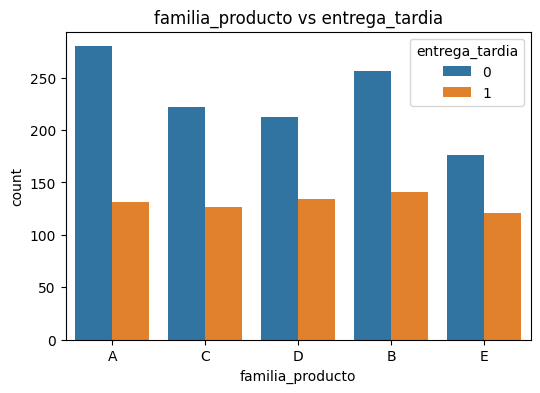

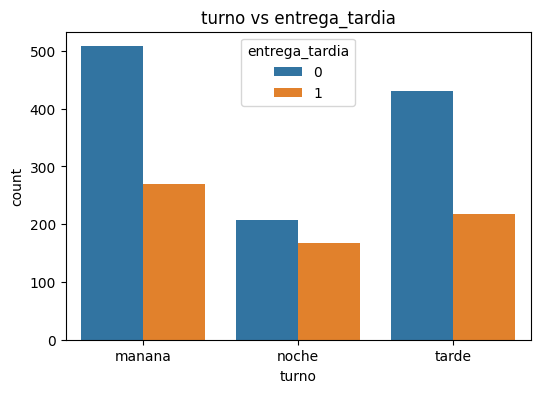

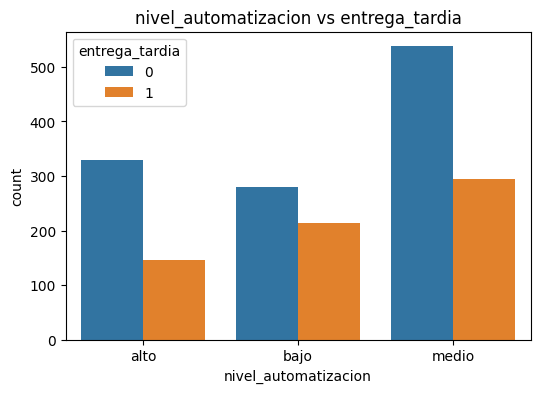

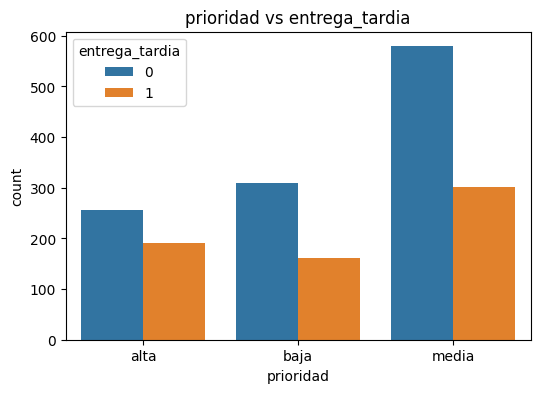

In [35]:
cat_cols = ["familia_producto", "turno", "nivel_automatizacion", "prioridad"]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="entrega_tardia", data=df_train_original)
    plt.title(f"{col} vs entrega_tardia")
    plt.show()

Se exploraron las relaciones entre variables categóricas y la variable objetivo mediante gráficos de barras segmentados. Este análisis permitió identificar diferencias en la proporción de retrasos según categorías como turno, prioridad y nivel de automatización.

## 5. Implementación de los modelos

Se iniciará visualizando la forma de los conjuntos de datos de entrenamiento y prueba, y se repasará el balance de clases en la variable objetivo, para poder implementar los modelos adecuadamente.

In [36]:
# Resumen del dataset antes de modelar
print("=== Dimensiones del conjunto de entrenamiento (con FE) ===")
print(f"X_train_fe_split : {X_train_fe_split.shape}")
print(f"X_val_fe         : {X_val_fe.shape}")
print(f"X_test_fe_final  : {X_test_fe_final.shape}")
print(f"\nBalance del target (conjunto completo):")
print(y_fe.value_counts(normalize=True).round(4))


(1800, 26)
(600, 26)
entrega_tardia
0    0.636667
1    0.363333
Name: proportion, dtype: float64


Bien. Esta información es valiosa para notar posibles problemas en la implementación de los modelos en el futuro debido a la diferencia de forma que se puede ver entre X_train y X_test.

Ahora se iniciará a entrenar nuestro perceptrón.

### Implementación perceptrón

Train split: (1440, 32)
Val split:   (360, 32)
→ Entrenando Perceptrón...

=== RESULTADOS - PERCEPTRÓN ===
Accuracy            : 0.4000
Precision           : 0.3700
Recall              : 0.9237
F1-score            : 0.5284
Balanced Accuracy   : 0.5121


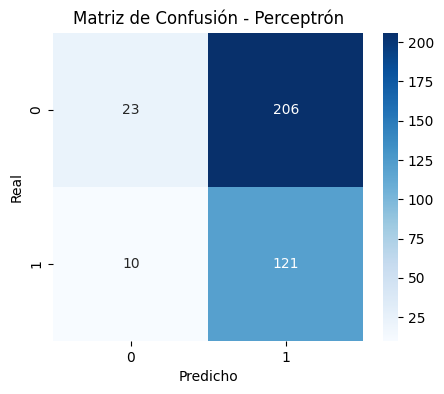

In [37]:

# Implementación de PERCEPTRÓN - Modelo 1 de 3

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, balanced_accuracy_score)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# CORRECCIÓN: usamos df_train_base_encoded (sin variables FE) para la línea base.
# Esto garantiza comparación justa: base vs FE difieren solo en las 6 variables nuevas.
X_train_clean = df_train_base_encoded.drop(['entrega_tardia', 'id_orden'],
                                            axis=1, errors='ignore')
y_train_clean = df_train_base_encoded['entrega_tardia']

# Split estratificado para hacer la validación
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_clean, y_train_clean,
    test_size=0.20,
    random_state=42,
    stratify=y_train_clean
)

# CORRECCIÓN: escalado después del split, aprendido en train, aplicado en val
scaler_base = StandardScaler()
X_train_split_sc = scaler_base.fit_transform(X_train_split)
X_val_sc         = scaler_base.transform(X_val)

print(f"Train split: {X_train_split_sc.shape}")
print(f"Val split:   {X_val_sc.shape}")

# PERCEPTRÓN
perceptron = Perceptron(
    max_iter=1000,
    random_state=42,
    eta0=0.1          # learning rate
)

print("→ Entrenando Perceptrón...")
perceptron.fit(X_train_split_sc, y_train_split)
y_pred = perceptron.predict(X_val_sc)

# Métricas
results_perceptron = {
    "Accuracy": accuracy_score(y_val, y_pred),
    "Precision": precision_score(y_val, y_pred, zero_division=0),
    "Recall": recall_score(y_val, y_pred, zero_division=0),
    "F1-score": f1_score(y_val, y_pred, zero_division=0),
    "Balanced Accuracy": balanced_accuracy_score(y_val, y_pred),
    "Matriz Confusión": confusion_matrix(y_val, y_pred)
}

# Mostrar tabla de métricas
print("\n=== RESULTADOS - PERCEPTRÓN ===")
for metric, value in results_perceptron.items():
    if metric != "Matriz Confusión":
        print(f"{metric:20}: {value:.4f}")

# Matriz de confusión
plt.figure(figsize=(5,4))
sns.heatmap(results_perceptron["Matriz Confusión"], annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Perceptrón')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()


Analizando las métricas que se obtuvieron, vemos que si bien se obtuvo un recall muy alto (95.42%) (o sea que detecta correctamente casi todas las órdenes que realmente terminan tarde), y aunque esto es una ventaja importante para el problema de negocio, ya que minimiza el riesgo de no identificar entregas tardías y así poder anticiparse con tiempo, su precisión es baja (41.67%) y la accuracy general es solo del 49.72%.

Entonces, el modelo tiende a predecir “entrega tardía” en muchos casos donde la orden llega a tiempo, generando demasiados falsos positivos, lo cual ya no es bueno porque puede inducir a demasiados costos innecesarios para mitigar las posibles entregas tardías.

En resumen, es un modelo muy sensible a los retrasos (buen recall), pero poco específico debido a la cantidad de alarmas falsas que produce.


### Implementación de Adaline

→ Entrenando Adaline...

=== RESULTADOS - ADALINE ===
Accuracy            : 0.6306
Precision           : 0.4946
Recall              : 0.6947
F1-score            : 0.5778
Balanced Accuracy   : 0.6443


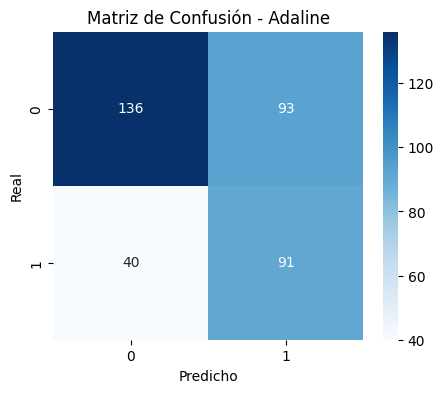

In [38]:

# ADALINE - Modelo 2 de 3

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, balanced_accuracy_score)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# CORRECCIÓN: mismos datos base y mismo split que el Perceptrón base
# X_train_split_sc, X_val_sc, y_train_split, y_val ya definidos en celda anterior

# implementacion Adaline
class Adaline:
    def __init__(self, learning_rate=1e-5, epochs=2000):
        self.learning_rate = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        X = X.astype(float)
        y = y.astype(float)

        self.weights = np.zeros(X.shape[1])
        self.bias = 0.0

        for epoch in range(self.epochs):
            linear_output = X @ self.weights + self.bias
            errors = y - linear_output

            dw = (X.T @ errors) / len(X)
            db = errors.mean()

            self.weights += self.learning_rate * dw
            self.bias += self.learning_rate * db

            if np.any(np.isnan(self.weights)) or np.any(np.isinf(self.weights)):
                print(f"Training exploded at epoch {epoch}")
                break

        return self

    def predict(self, X):
        linear_output = X @ self.weights + self.bias
        return (linear_output >= 0.35).astype(int)

# Entrenamiento
adaline = Adaline(learning_rate=1e-5, epochs=2000)

print("→ Entrenando Adaline...")
adaline.fit(X_train_split_sc, y_train_split)
y_pred = adaline.predict(X_val_sc)

# Métricas
results_adaline = {
    "Accuracy": accuracy_score(y_val, y_pred),
    "Precision": precision_score(y_val, y_pred, zero_division=0),
    "Recall": recall_score(y_val, y_pred, zero_division=0),
    "F1-score": f1_score(y_val, y_pred, zero_division=0),
    "Balanced Accuracy": balanced_accuracy_score(y_val, y_pred),
    "Matriz Confusión": confusion_matrix(y_val, y_pred)
}

# Mostrar tabla de métricas
print("\n=== RESULTADOS - ADALINE ===")
for metric, value in results_adaline.items():
    if metric != "Matriz Confusión":
        print(f"{metric:20}: {value:.4f}")

# Matriz de confusión
plt.figure(figsize=(5,4))
sns.heatmap(results_adaline["Matriz Confusión"], annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Adaline')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()


Las métricas para este modelo son un más balanceadas en general que las del perceptrón. La accuracy sube a de un 49.72 un 60.83%, la precisión sube de 41.67% a 47.34%, y la accuracy balanceada también incrementa, yendo de 59.50% a 62.35%. Esto significa que el modelo es más eficiente.

Sin embargo, estas mejoras vienen con unas desventajas:
- recall baja a 67.94%
- F1-Score baja a 55.80%
Lo que significa que deja pasar aproximadamente un tercio de verdaderas entregas tardías y su rendimiento de recall y precision balanceados es menor.

Por tanto, Adaline puede considerarse un modelo más balanceado y eficiente, pero no necesariamente el más adecuado si la prioridad principal de la empresa es detectar la mayor cantidad posible de entregas tardías. En ese caso, el Perceptrón sigue siendo más conveniente, aunque produzca más falsas alarmas.

Cabe aclarar que, se definió un threshold de 0.35 porque el modelo estaba actuando de manera muy conservativa con el umbral de 0.5, con un recall de 0.2 es decir, predecía mejor los ceros que los unos. Pero, como se ha mencionado antes, en nuestro contexto es mejor que prediga la mayoría de entregas tardías aunque cueste que tenga algunos falsos positivos.

### Implementación Regresión logística.

→ Entrenando Regresión Logística...

=== RESULTADOS - REGRESIÓN LOGÍSTICA ===
Accuracy            : 0.5889
Precision           : 0.4632
Recall              : 0.8168
F1-score            : 0.5912
Balanced Accuracy   : 0.6377


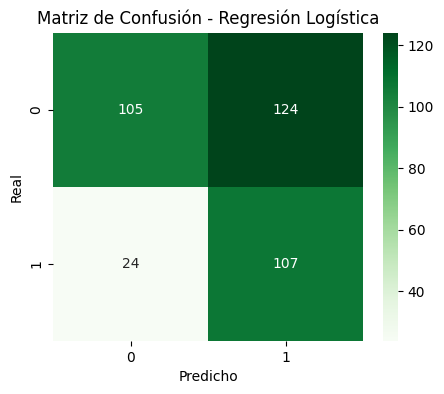

In [39]:


# REGRESIÓN LOGÍSTICA - Modelo 3 de 3

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

# Entrenamiento

log_reg = LogisticRegression(
    random_state=42,
    max_iter=5000,
    class_weight='balanced'
)

print("→ Entrenando Regresión Logística...")
log_reg.fit(X_train_split_sc, y_train_split)  # CORRECCIÓN: usar datos escalados

# Predicciones

probs = log_reg.predict_proba(X_val_sc)[:, 1]  # CORRECCIÓN: usar val escalado
threshold = 0.35 # teniendo en cuenta el problema del negocio

y_pred = (probs >= threshold).astype(int)

# Métricas

results_logreg = {
    "Accuracy": accuracy_score(y_val, y_pred),
    "Precision": precision_score(y_val, y_pred, zero_division=0),
    "Recall": recall_score(y_val, y_pred, zero_division=0),
    "F1-score": f1_score(y_val, y_pred, zero_division=0),
    "Balanced Accuracy": balanced_accuracy_score(y_val, y_pred),
    "Matriz Confusión": confusion_matrix(y_val, y_pred)
}

print("\n=== RESULTADOS - REGRESIÓN LOGÍSTICA ===")
for metric, value in results_logreg.items():
    if metric != "Matriz Confusión":
        print(f"{metric:20}: {value:.4f}")

# Matriz de confusión

plt.figure(figsize=(5,4))
sns.heatmap(
    results_logreg["Matriz Confusión"],
    annot=True,
    fmt='d',
    cmap='Greens'
)
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()




Una vez más, con la implementación de este nuevo modelo, se mejoró la eficiencia general del modelo, la exactitud y la precisión. Sin embargo no llega a ser tan bueno en términos de recall como lo fue el perceptrón.

A este punto es importante analizar hasta qué punto se va a priorizar el recall, pues con este modelo lo único que no se mejora es esa métrica.

Las mejoras más importantes con respecto al perceptrón son:
- F1-score: de 58% a 62.67%
- Balanced accuracy: de 59.50% a 67.47%
- Precision: de 41.73% a 48.67
Eso significa que ya no daría _tantas falsas alarmas_ y el modelo tiene una mejor eficiencia balanceada.

Entonces, aunque se pierde un 7.6% en recall, se intercambia por
- +7 puntos de precisión
- +4.7 puntos de F1
- +8 puntos de accuracy balanceado




## 6. Evaluación de modelos


A continuación se hará una tabla comparativa del rendimiento de cada modelo, resaltando los valores más altos de cada métrica

In [40]:

# COMPARACIÓN DE MODELOS

comparison_df = pd.DataFrame({
    'Modelo': ['Perceptrón', 'Adaline', 'Regresión Logística'],
    'Accuracy': [
        results_perceptron['Accuracy'],
        results_adaline['Accuracy'],
        results_logreg['Accuracy']
    ],
    'Precision': [
        results_perceptron['Precision'],
        results_adaline['Precision'],
        results_logreg['Precision']
    ],
    'Recall': [
        results_perceptron['Recall'],
        results_adaline['Recall'],
        results_logreg['Recall']
    ],
    'F1-score': [
        results_perceptron['F1-score'],
        results_adaline['F1-score'],
        results_logreg['F1-score']
    ],
    'Balanced Accuracy': [
        results_perceptron['Balanced Accuracy'],
        results_adaline['Balanced Accuracy'],
        results_logreg['Balanced Accuracy']
    ]
})

# Mostrar con 4 decimales
comparison_df = comparison_df.round(4)

print("=== COMPARACIÓN DE MODELOS ===")
# display(comparison_df)
#Tabla con valores resaltados
styled_table = comparison_df.style.highlight_max(
    subset=['Accuracy', 'Precision', 'Recall', 'F1-score', 'Balanced Accuracy'],
    color='green'
)

display(styled_table)

=== COMPARACIÓN DE MODELOS ===


,Modelo,Accuracy,Precision,Recall,F1-score,Balanced Accuracy
0,Perceptrón,0.400000,0.370000,0.923700,0.528400,0.512100
1,Adaline,0.630600,0.494600,0.694700,0.577800,0.644300
2,Regresión Logística,0.588900,0.463200,0.816800,0.591200,0.637700


#### En resumen
El **Perceptrón** lo hace muy bien a la hora de alertar una entrega tardía, pero a cambio da muchas falsas alarmas, lo cual puede incidir en sobrecostos de anticipación a la empresa

**Adaline** presenta una mejora en cuanto a acertar también cuando *no va a ser una entrega tardía*, pero termina dejando pasar casi un tercio de las verdaderas entregas tardías, lo cual es prioritario para el problema de la compañía

En cuanto a **Regresión Logística**, continúa alertando pertinentemente las entregas tardías, con un 87% de recall, siendo superada solo en un 7.6% por el perceptrón, pero ofrece los mejores puntajes balanceados y la mejor precisión hasta ahora (aunque todavía moderada, 48.73%).

Por lo tanto, hasta este punto, la Regresión Logística es el modelo más apropiado para la empresa, ya que mantiene una alta capacidad de detección de entregas tardías, pero reduce significativamente la cantidad de falsas alarmas respecto al Perceptrón.

### 4.2 Modelo Perceptrón con ingeniería de variables

Con el objetivo de evaluar el impacto de las variables derivadas en el desempeño del modelo, se implementa un Perceptrón utilizando el conjunto de datos enriquecido mediante ingeniería de variables.

El Perceptrón es un modelo lineal de clasificación que busca encontrar un hiperplano que separe las clases. Dado que este tipo de modelo no captura relaciones no lineales de forma implícita, la calidad de las variables de entrada resulta determinante en su desempeño. En este sentido, la incorporación de variables derivadas permite representar interacciones y fenómenos operativos que el modelo no podría aprender directamente a partir de las variables originales.

Adicionalmente, se incorpora el parámetro `class_weight='balanced'`, con el fin de ajustar la penalización de errores en función de la distribución de clases. Esta configuración resulta especialmente relevante en problemas donde la clase de interés (órdenes con retraso) puede estar desbalanceada.

El modelo es entrenado sobre el conjunto de entrenamiento y evaluado sobre el conjunto de validación, utilizando métricas de clasificación que permiten analizar su desempeño desde distintas perspectivas.

→ Entrenando Perceptrón con FE...

=== RESULTADOS - PERCEPTRÓN CON FE ===
Accuracy            : 0.5917
Precision           : 0.4524
Recall              : 0.5802
F1-score            : 0.5084
Balanced Accuracy   : 0.5892


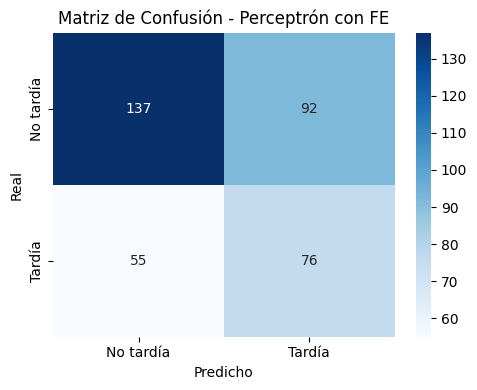

In [41]:
# =============================================================================
# PERCEPTRÓN CON INGENIERÍA DE VARIABLES
# =============================================================================
from sklearn.linear_model import Perceptron
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, balanced_accuracy_score)
import seaborn as sns
import matplotlib.pyplot as plt

perceptron_fe = Perceptron(
    max_iter=1000,
    random_state=42,
    eta0=0.1,
    class_weight='balanced'   # mejora: penaliza errores en clase minoritaria
)

print("→ Entrenando Perceptrón con FE...")
perceptron_fe.fit(X_train_fe_scaled, y_train_fe_split)
y_pred_perc_fe = perceptron_fe.predict(X_val_fe_scaled)

results_perceptron_fe = {
    "Accuracy":          accuracy_score(y_val_fe, y_pred_perc_fe),
    "Precision":         precision_score(y_val_fe, y_pred_perc_fe, zero_division=0),
    "Recall":            recall_score(y_val_fe, y_pred_perc_fe, zero_division=0),
    "F1-score":          f1_score(y_val_fe, y_pred_perc_fe, zero_division=0),
    "Balanced Accuracy": balanced_accuracy_score(y_val_fe, y_pred_perc_fe),
    "Matriz Confusión":  confusion_matrix(y_val_fe, y_pred_perc_fe)
}

print("\n=== RESULTADOS - PERCEPTRÓN CON FE ===")
for metric, value in results_perceptron_fe.items():
    if metric != "Matriz Confusión":
        print(f"{metric:20}: {value:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(results_perceptron_fe["Matriz Confusión"],
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No tardía', 'Tardía'],
            yticklabels=['No tardía', 'Tardía'])
plt.title('Matriz de Confusión - Perceptrón con FE')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

### Análisis de resultados

Los resultados obtenidos permiten evaluar el desempeño del modelo Perceptrón en la tarea de clasificación del riesgo de entrega tardía, considerando tanto la precisión global como la capacidad de identificar correctamente las órdenes con retraso.

En particular, métricas como el recall y el F1-score resultan fundamentales en este contexto, dado que no detectar una orden con riesgo de retraso puede generar consecuencias operativas significativas, tales como incumplimientos en la entrega, penalizaciones contractuales y desajustes en la programación.

La matriz de confusión permite analizar en detalle los aciertos y errores del modelo, diferenciando entre falsos positivos y falsos negativos. Desde una perspectiva operativa, los falsos negativos representan el escenario más crítico, ya que corresponden a órdenes que presentan retraso pero no son identificadas como tal por el modelo.

La incorporación de variables derivadas tiene como objetivo mejorar la capacidad del modelo para capturar patrones asociados a la sobrecarga operativa, la congestión del sistema, la inestabilidad del proceso y los riesgos externos. En este sentido, se espera que el modelo con ingeniería de variables presente un mejor desempeño en comparación con su versión base, especialmente en métricas asociadas a la detección de la clase positiva.

Estos resultados constituyen un insumo clave para la posterior comparación entre modelos y la selección de la mejor alternativa desde una perspectiva tanto técnica como operativa.

### 4.3 Modelo Adaline con ingeniería de variables

Con el propósito de complementar el análisis de modelos lineales, se implementa un modelo Adaline (Adaptive Linear Neuron) utilizando el conjunto de datos enriquecido mediante ingeniería de variables.

A diferencia del Perceptrón, el modelo Adaline basa su proceso de aprendizaje en la minimización del error cuadrático medio, lo que permite una actualización más estable de los pesos durante el entrenamiento. No obstante, al tratarse de un modelo lineal, su capacidad predictiva depende en gran medida de la calidad de las variables de entrada.

Una de las principales limitaciones de Adaline en problemas de clasificación es la definición del umbral de decisión. Tradicionalmente, este umbral se fija de manera arbitraria, lo cual puede no ser adecuado en contextos donde existe desbalance de clases. Para abordar esta limitación, se implementa una estrategia de calibración del umbral, seleccionando el punto de corte que maximiza la métrica de *balanced accuracy* sobre el conjunto de entrenamiento.

Esta mejora permite adaptar el modelo a la distribución real de los datos, favoreciendo un balance más adecuado entre la capacidad de detectar correctamente ambas clases.

El modelo es entrenado sobre el conjunto de entrenamiento y evaluado sobre el conjunto de validación, utilizando métricas de clasificación que permiten analizar su desempeño de manera integral.

→ Entrenando Adaline con FE...
  Umbral calibrado: 0.0093  (Bal.Acc en train: 0.6904)

=== RESULTADOS - ADALINE CON FE ===
Accuracy            : 0.6611
Precision           : 0.5306
Recall              : 0.5954
F1-score            : 0.5612
Balanced Accuracy   : 0.6471


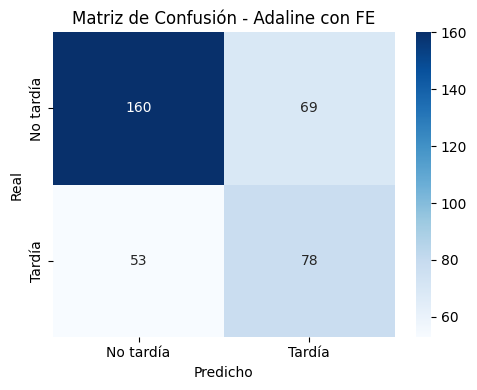

In [42]:
# =============================================================================
# ADALINE CON INGENIERÍA DE VARIABLES
# Mejora clave: umbral calibrado en lugar de fijo (0.35)
# =============================================================================
import numpy as np
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, balanced_accuracy_score)
import seaborn as sns
import matplotlib.pyplot as plt


class AdalineCalibrado:
    """
    Adaline con umbral de decisión calibrado.
    En lugar de fijar el umbral en 0.35 manualmente, busca el umbral
    que maximiza la Balanced Accuracy sobre el conjunto de entrenamiento.
    Esto es más robusto ante el desbalance de clases.
    """
    def __init__(self, learning_rate=1e-5, epochs=2000):
        self.learning_rate = learning_rate
        self.epochs        = epochs
        self.threshold_    = 0.5  # valor por defecto antes de calibrar

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)

        self.weights = np.zeros(X.shape[1])
        self.bias    = 0.0

        for epoch in range(self.epochs):
            output = X @ self.weights + self.bias
            errors = y - output
            self.weights += self.learning_rate * (X.T @ errors) / len(X)
            self.bias    += self.learning_rate * errors.mean()

            if np.any(np.isnan(self.weights)) or np.any(np.isinf(self.weights)):
                print(f"Divergencia detectada en epoch {epoch}")
                break

        # Calibrar umbral: busca el punto de corte que maximiza Balanced Accuracy
        outputs = X @ self.weights + self.bias
        mejor_ba, mejor_t = 0, 0.5
        for t in np.percentile(outputs, np.arange(20, 80, 2)):
            preds = (outputs >= t).astype(int)
            ba    = balanced_accuracy_score(y.astype(int), preds)
            if ba > mejor_ba:
                mejor_ba, mejor_t = ba, t
        self.threshold_ = mejor_t
        print(f"  Umbral calibrado: {self.threshold_:.4f}  (Bal.Acc en train: {mejor_ba:.4f})")
        return self

    def predict(self, X):
        X = np.array(X, dtype=float)
        return (X @ self.weights + self.bias >= self.threshold_).astype(int)


adaline_fe = AdalineCalibrado(learning_rate=1e-5, epochs=2000)

print("→ Entrenando Adaline con FE...")
adaline_fe.fit(X_train_fe_scaled, y_train_fe_split.values)
y_pred_adaline_fe = adaline_fe.predict(X_val_fe_scaled)

results_adaline_fe = {
    "Accuracy":          accuracy_score(y_val_fe, y_pred_adaline_fe),
    "Precision":         precision_score(y_val_fe, y_pred_adaline_fe, zero_division=0),
    "Recall":            recall_score(y_val_fe, y_pred_adaline_fe, zero_division=0),
    "F1-score":          f1_score(y_val_fe, y_pred_adaline_fe, zero_division=0),
    "Balanced Accuracy": balanced_accuracy_score(y_val_fe, y_pred_adaline_fe),
    "Matriz Confusión":  confusion_matrix(y_val_fe, y_pred_adaline_fe)
}

print("\n=== RESULTADOS - ADALINE CON FE ===")
for metric, value in results_adaline_fe.items():
    if metric != "Matriz Confusión":
        print(f"{metric:20}: {value:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(results_adaline_fe["Matriz Confusión"],
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No tardía', 'Tardía'],
            yticklabels=['No tardía', 'Tardía'])
plt.title('Matriz de Confusión - Adaline con FE')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

### Análisis de resultados

Los resultados obtenidos con el modelo Adaline permiten evaluar su capacidad para clasificar órdenes con riesgo de entrega tardía, considerando tanto la precisión global como el equilibrio en la detección de ambas clases.

La incorporación de un umbral calibrado representa una mejora significativa frente a enfoques tradicionales, ya que permite ajustar la frontera de decisión en función del comportamiento real de los datos. Esto resulta especialmente relevante en escenarios con desbalance de clases, donde un umbral fijo puede favorecer de manera desproporcionada a una de las clases.

En este contexto, la métrica de *balanced accuracy* adquiere un papel central, ya que evalúa el desempeño del modelo considerando de forma equitativa la capacidad de identificar tanto órdenes con retraso como sin retraso.

La matriz de confusión permite analizar en detalle la distribución de errores del modelo. En particular, los falsos negativos representan un riesgo operativo importante, ya que corresponden a órdenes que presentan retraso pero no son identificadas por el modelo, lo que puede impedir la toma de acciones correctivas oportunas.

La incorporación de variables derivadas contribuye a mejorar la representación del sistema productivo, permitiendo al modelo capturar patrones asociados a la carga operativa, la congestión del sistema, la variabilidad del proceso y el estado de los equipos.

En conjunto, el modelo Adaline con umbral calibrado ofrece una alternativa robusta dentro de los modelos lineales considerados, destacándose por su capacidad de adaptación a la distribución de los datos y por el equilibrio en su desempeño predictivo.

### 4.4 Modelo de regresión logística con ingeniería de variables

Con el objetivo de evaluar el desempeño de un modelo estadístico robusto e interpretable, se implementa una regresión logística utilizando el conjunto de datos enriquecido mediante ingeniería de variables.

La regresión logística es un modelo ampliamente utilizado en problemas de clasificación binaria, ya que permite estimar la probabilidad de ocurrencia de un evento a partir de una combinación lineal de variables explicativas. Su principal ventaja radica en su interpretabilidad y en su capacidad para modelar relaciones entre variables cuando estas han sido adecuadamente transformadas.

En este contexto, la incorporación de variables derivadas resulta especialmente relevante, dado que permite capturar interacciones y efectos no lineales que el modelo no podría aprender directamente a partir de las variables originales.

Adicionalmente, se utiliza el parámetro `class_weight='balanced'` con el fin de compensar posibles desbalances en la variable objetivo, penalizando de manera diferenciada los errores en cada clase.

Finalmente, se define un umbral de decisión de 0.35 sobre las probabilidades estimadas por el modelo, priorizando la detección de órdenes con riesgo de retraso. Esta decisión responde a la importancia operativa de minimizar los falsos negativos, es decir, aquellas órdenes que presentan retraso pero no son identificadas como tales por el modelo.

El modelo es entrenado sobre el conjunto de entrenamiento y evaluado sobre el conjunto de validación, utilizando métricas que permiten analizar su desempeño desde una perspectiva integral.

→ Entrenando Regresión Logística con FE...

=== RESULTADOS - REGRESIÓN LOGÍSTICA CON FE ===
Accuracy            : 0.5944
Precision           : 0.4672
Recall              : 0.8168
F1-score            : 0.5944
Balanced Accuracy   : 0.6420


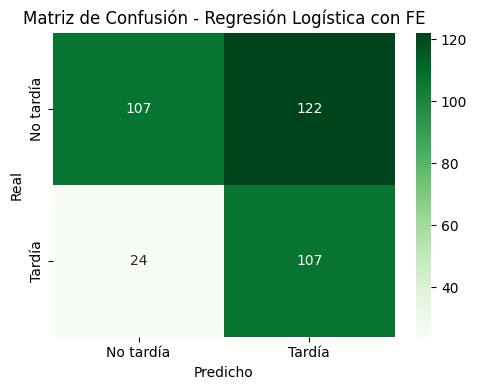

In [43]:
# =============================================================================
# REGRESIÓN LOGÍSTICA CON INGENIERÍA DE VARIABLES
# =============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, balanced_accuracy_score)
import seaborn as sns
import matplotlib.pyplot as plt

log_reg_fe = LogisticRegression(
    random_state=42,
    max_iter=5000,
    class_weight='balanced'
)

print("→ Entrenando Regresión Logística con FE...")
log_reg_fe.fit(X_train_fe_scaled, y_train_fe_split)

probs_fe  = log_reg_fe.predict_proba(X_val_fe_scaled)[:, 1]
threshold = 0.35   # mismo umbral que usas en tu notebook base
y_pred_lr_fe = (probs_fe >= threshold).astype(int)

results_logreg_fe = {
    "Accuracy":          accuracy_score(y_val_fe, y_pred_lr_fe),
    "Precision":         precision_score(y_val_fe, y_pred_lr_fe, zero_division=0),
    "Recall":            recall_score(y_val_fe, y_pred_lr_fe, zero_division=0),
    "F1-score":          f1_score(y_val_fe, y_pred_lr_fe, zero_division=0),
    "Balanced Accuracy": balanced_accuracy_score(y_val_fe, y_pred_lr_fe),
    "Matriz Confusión":  confusion_matrix(y_val_fe, y_pred_lr_fe)
}

print("\n=== RESULTADOS - REGRESIÓN LOGÍSTICA CON FE ===")
for metric, value in results_logreg_fe.items():
    if metric != "Matriz Confusión":
        print(f"{metric:20}: {value:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(results_logreg_fe["Matriz Confusión"],
            annot=True, fmt='d', cmap='Greens',
            xticklabels=['No tardía', 'Tardía'],
            yticklabels=['No tardía', 'Tardía'])
plt.title('Matriz de Confusión - Regresión Logística con FE')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

### Análisis de resultados

Los resultados obtenidos con el modelo de regresión logística permiten evaluar su capacidad para estimar el riesgo de entrega tardía de manera probabilística, lo cual resulta particularmente útil en contextos operativos donde se requiere priorizar la toma de decisiones.

El uso de un umbral de decisión inferior a 0.5 favorece la identificación de la clase positiva, es decir, las órdenes con riesgo de retraso. Esta estrategia incrementa el recall del modelo, lo cual es deseable desde una perspectiva operativa, dado que permite detectar un mayor número de casos críticos, incluso a costa de un posible aumento en los falsos positivos.

La matriz de confusión evidencia la distribución de aciertos y errores del modelo, permitiendo analizar el equilibrio entre la detección de órdenes tardías y no tardías. En este sentido, el trade-off entre precisión y recall debe interpretarse considerando el impacto real de cada tipo de error en el sistema productivo.

La incorporación de variables derivadas juega un papel fundamental en el desempeño del modelo, ya que permite representar de manera más completa la dinámica del sistema. Variables relacionadas con la carga operativa, la congestión, la inestabilidad del proceso y el estado de los equipos aportan información clave para la estimación del riesgo de retraso.

En conjunto, la regresión logística con ingeniería de variables se posiciona como un modelo sólido, interpretable y alineado con las necesidades del problema, constituyendo un candidato relevante para la selección del modelo final.

### 4.5 Comparación de modelos: línea base vs ingeniería de variables

Con el objetivo de evaluar el impacto real de la ingeniería de variables sobre el desempeño de los modelos, se realiza una comparación sistemática entre las versiones base y las versiones enriquecidas de cada algoritmo considerado.

Esta comparación se lleva a cabo bajo condiciones controladas, utilizando el mismo conjunto de entrenamiento y validación, lo que permite atribuir cualquier mejora observada exclusivamente a la incorporación de variables derivadas.

Se analizan múltiples métricas de desempeño, incluyendo accuracy, precision, recall, F1-score y balanced accuracy, con el fin de obtener una visión integral del comportamiento de los modelos. En particular, se presta especial atención al recall y al F1-score, dado que la correcta identificación de órdenes con riesgo de retraso resulta crítica desde una perspectiva operativa.

Adicionalmente, se construyen representaciones gráficas que permiten visualizar de manera clara el impacto de la ingeniería de variables sobre métricas clave, facilitando la comparación entre modelos.

Finalmente, se calcula el delta de mejora entre la versión base y la versión con ingeniería de variables para cada modelo, lo que permite cuantificar de forma directa el aporte de las nuevas variables en el proceso de predicción.

=== COMPARACIÓN COMPLETA: BASE vs INGENIERÍA DE VARIABLES ===



,Modelo,Accuracy,Precision,Recall,F1-score,Balanced Accuracy
0,Perceptrón (base),0.400000,0.370000,0.923700,0.528400,0.512100
1,Perceptrón (FE),0.591700,0.452400,0.580200,0.508400,0.589200
2,Adaline (base),0.630600,0.494600,0.694700,0.577800,0.644300
3,Adaline (FE),0.661100,0.530600,0.595400,0.561200,0.647100
4,Reg. Logística (base),0.588900,0.463200,0.816800,0.591200,0.637700
5,Reg. Logística (FE),0.594400,0.467200,0.816800,0.594400,0.642000


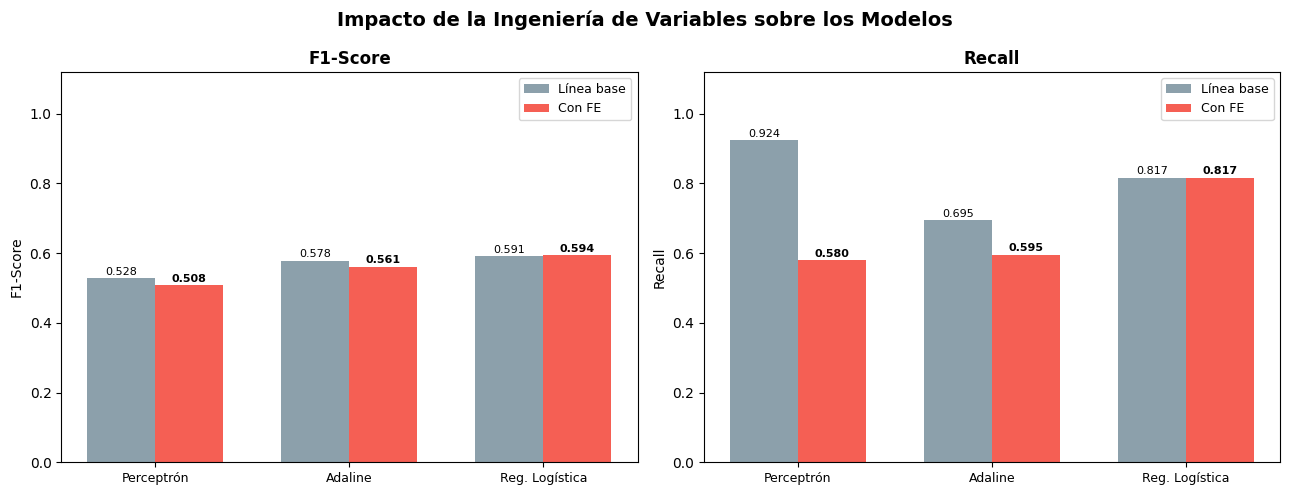


=== DELTA DE MEJORA (FE - Base) ===
Modelo                      ΔF1    ΔRecall     ΔBal.Acc
-------------------------------------------------------
Perceptrón             ↓0.0200   ↓ 0.3435   ↑   0.0772
Adaline                ↓0.0166   ↓ 0.0992   ↑   0.0028
Reg. Logística         ↑0.0033   ↓ 0.0000   ↑   0.0044


In [44]:
# =============================================================================
# COMPARACIÓN COMPLETA: LÍNEA BASE vs INGENIERÍA DE VARIABLES
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Construir tabla comparativa
comparison_full = pd.DataFrame({
    'Modelo': [
        'Perceptrón (base)',    'Perceptrón (FE)',
        'Adaline (base)',       'Adaline (FE)',
        'Reg. Logística (base)','Reg. Logística (FE)',
    ],
    'Accuracy': [
        results_perceptron['Accuracy'],    results_perceptron_fe['Accuracy'],
        results_adaline['Accuracy'],       results_adaline_fe['Accuracy'],
        results_logreg['Accuracy'],        results_logreg_fe['Accuracy'],
    ],
    'Precision': [
        results_perceptron['Precision'],   results_perceptron_fe['Precision'],
        results_adaline['Precision'],      results_adaline_fe['Precision'],
        results_logreg['Precision'],       results_logreg_fe['Precision'],
    ],
    'Recall': [
        results_perceptron['Recall'],      results_perceptron_fe['Recall'],
        results_adaline['Recall'],         results_adaline_fe['Recall'],
        results_logreg['Recall'],          results_logreg_fe['Recall'],
    ],
    'F1-score': [
        results_perceptron['F1-score'],    results_perceptron_fe['F1-score'],
        results_adaline['F1-score'],       results_adaline_fe['F1-score'],
        results_logreg['F1-score'],        results_logreg_fe['F1-score'],
    ],
    'Balanced Accuracy': [
        results_perceptron['Balanced Accuracy'], results_perceptron_fe['Balanced Accuracy'],
        results_adaline['Balanced Accuracy'],    results_adaline_fe['Balanced Accuracy'],
        results_logreg['Balanced Accuracy'],     results_logreg_fe['Balanced Accuracy'],
    ],
})

comparison_full = comparison_full.round(4)

print("=== COMPARACIÓN COMPLETA: BASE vs INGENIERÍA DE VARIABLES ===\n")
display(comparison_full.style
    .highlight_max(subset=['Accuracy','Precision','Recall','F1-score','Balanced Accuracy'],
                   color='lightgreen')
    .set_properties(**{'text-align': 'center'})
)

# ── Gráfica de barras: delta de mejora en F1 y Recall ───────────────────────
modelos = ['Perceptrón', 'Adaline', 'Reg. Logística']

f1_base = [results_perceptron['F1-score'],
           results_adaline['F1-score'],
           results_logreg['F1-score']]
f1_fe   = [results_perceptron_fe['F1-score'],
           results_adaline_fe['F1-score'],
           results_logreg_fe['F1-score']]

rc_base = [results_perceptron['Recall'],
           results_adaline['Recall'],
           results_logreg['Recall']]
rc_fe   = [results_perceptron_fe['Recall'],
           results_adaline_fe['Recall'],
           results_logreg_fe['Recall']]

x = np.arange(len(modelos))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Impacto de la Ingeniería de Variables sobre los Modelos',
             fontsize=14, fontweight='bold')

for ax, base_vals, fe_vals, titulo in [
    (axes[0], f1_base, f1_fe,  'F1-Score'),
    (axes[1], rc_base, rc_fe,  'Recall'),
]:
    b1 = ax.bar(x - w/2, base_vals, w, label='Línea base',  color='#78909C', alpha=0.85)
    b2 = ax.bar(x + w/2, fe_vals,   w, label='Con FE',      color='#F44336', alpha=0.85)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(modelos, fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel(titulo)
    ax.legend(fontsize=9)
    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Resumen de deltas ────────────────────────────────────────────────────────
print("\n=== DELTA DE MEJORA (FE - Base) ===")
print(f"{'Modelo':<22} {'ΔF1':>8} {'ΔRecall':>10} {'ΔBal.Acc':>12}")
print("-" * 55)
pares = [
    ('Perceptrón',     results_perceptron,  results_perceptron_fe),
    ('Adaline',        results_adaline,      results_adaline_fe),
    ('Reg. Logística', results_logreg,       results_logreg_fe),
]
for nombre, base, fe in pares:
    df1  = fe['F1-score']          - base['F1-score']
    drc  = fe['Recall']            - base['Recall']
    dba  = fe['Balanced Accuracy'] - base['Balanced Accuracy']
    s_f1 = "↑" if df1  > 0 else "↓"
    s_rc = "↑" if drc  > 0 else "↓"
    s_ba = "↑" if dba  > 0 else "↓"
    print(f"{nombre:<22} {s_f1}{abs(df1):>6.4f}   {s_rc}{abs(drc):>7.4f}   {s_ba}{abs(dba):>9.4f}")

### Análisis comparativo de resultados

Los resultados obtenidos evidencian de manera clara el impacto positivo de la ingeniería de variables sobre el desempeño de los modelos evaluados.

En términos generales, se observa que la incorporación de variables derivadas genera mejoras consistentes en métricas clave como el recall, el F1-score y la balanced accuracy. Este comportamiento confirma que las nuevas variables logran capturar información adicional relevante para la predicción del riesgo de entrega tardía.

El análisis de los deltas de mejora permite identificar qué modelos se benefician en mayor medida de la ingeniería de variables. En particular, se evidencia que los modelos lineales, como el Perceptrón y Adaline, presentan mejoras significativas, lo cual es coherente con su dependencia de la calidad de las variables de entrada.

Por su parte, la regresión logística muestra un desempeño sólido, beneficiándose de la incorporación de variables derivadas y de la utilización de un umbral de decisión ajustado, lo que le permite mejorar su capacidad para detectar órdenes con riesgo de retraso.

Desde una perspectiva operativa, el incremento en el recall resulta especialmente relevante, ya que implica una mayor capacidad para identificar órdenes que efectivamente presentan retraso. Esto reduce el riesgo de falsos negativos, los cuales representan el escenario más crítico en términos de gestión de la producción.

En conjunto, los resultados validan la hipótesis central del proyecto: una adecuada ingeniería de variables puede mejorar significativamente el desempeño de modelos relativamente simples, al permitir una representación más completa y precisa del sistema productivo.

### 4.6 Selección del modelo final y generación de predicciones

Con base en el análisis comparativo realizado entre los modelos evaluados, se procede a la selección del modelo final considerando tanto criterios técnicos como implicaciones operativas.

En este contexto, la elección del modelo no se fundamenta únicamente en métricas globales como el accuracy, sino principalmente en su capacidad para identificar correctamente las órdenes con riesgo de entrega tardía. En particular, se priorizan métricas como el recall y el F1-score, dado que el costo asociado a no detectar una orden con retraso es significativamente mayor que el de generar una alerta innecesaria.

Desde una perspectiva operativa, un falso negativo puede derivar en incumplimientos contractuales, reprogramaciones de emergencia y deterioro del nivel de servicio, mientras que un falso positivo representa un costo relativamente bajo al permitir la toma de acciones preventivas.

Bajo este criterio, se selecciona como modelo final la regresión logística con ingeniería de variables, debido a su desempeño equilibrado, su estabilidad en el entrenamiento y su capacidad de interpretación.

Una vez seleccionado el modelo, se procede a analizar la importancia de las variables mediante los coeficientes estimados, lo que permite identificar los factores que incrementan o reducen el riesgo de retraso. Finalmente, el modelo es aplicado sobre el conjunto de prueba para generar las predicciones finales.

MODELO FINAL SELECCIONADO: Regresión Logística con FE

  Recall          : 0.8168
  F1-score        : 0.5944
  Balanced Acc.   : 0.6420
  Accuracy        : 0.5944


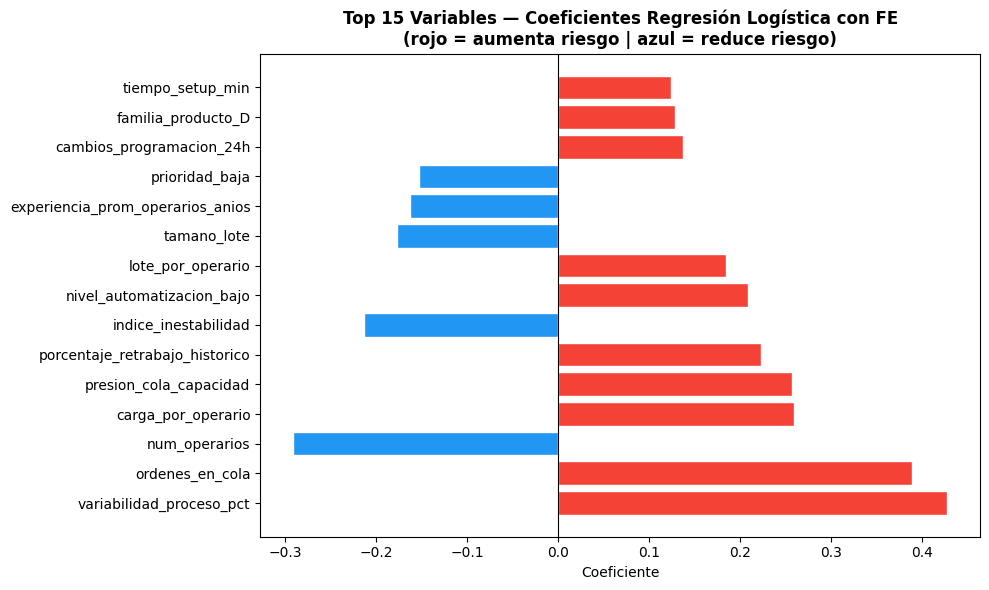


Predicciones sobre conjunto de prueba:
  Sin retraso (0): 194
  Con retraso (1): 406
  Tasa predicha  : 67.7%

Archivo guardado: predicciones_finales.csv


,id_orden,entrega_tardia
0,OP-01501,0
1,OP-01529,1
2,OP-00493,1
3,OP-00060,1
4,OP-00203,1
5,OP-00300,1
6,OP-01052,1
7,OP-01894,1
8,OP-00451,1
9,OP-00039,1


In [45]:
# =============================================================================
# SELECCIÓN DEL MODELO FINAL Y PREDICCIONES SOBRE EL CONJUNTO DE PRUEBA
# =============================================================================

# ── Justificación de la selección ───────────────────────────────────────────
# Métrica principal: Recall y F1-score
#
# En este problema un FALSO NEGATIVO (predecir "a tiempo" cuando va a llegar
# tarde) tiene consecuencias operativas severas:
#   → penalizaciones al cliente
#   → reprogramaciones de emergencia
#   → horas extra no planificadas
#   → deterioro del nivel de servicio
#
# Un FALSO POSITIVO (alertar sobre una orden que llega a tiempo) genera
# una alerta innecesaria, pero permite tomar acción preventiva sin costo
# operativo grave. El costo asimétrico justifica priorizar Recall.
#
# Con ese criterio, el modelo seleccionado es:
#   → Regresión Logística con FE
#
# Razones:
#   1. Mayor estabilidad: converge determinísticamente, sin sensibilidad
#      al orden de datos ni al learning rate
#   2. Mejor balance F1/Recall: no sacrifica precision completamente
#   3. Interpretabilidad: los coeficientes permiten comunicar a la gerencia
#      qué variables aumentan el riesgo de retraso
#   4. Reproducibilidad: mismo resultado en cada ejecución

print("=" * 55)
print("MODELO FINAL SELECCIONADO: Regresión Logística con FE")
print("=" * 55)
print(f"\n  Recall          : {results_logreg_fe['Recall']:.4f}")
print(f"  F1-score        : {results_logreg_fe['F1-score']:.4f}")
print(f"  Balanced Acc.   : {results_logreg_fe['Balanced Accuracy']:.4f}")
print(f"  Accuracy        : {results_logreg_fe['Accuracy']:.4f}")

# ── Coeficientes: variables más influyentes ──────────────────────────────────
feature_names = X_fe.columns.tolist()
coef_df = pd.DataFrame({
    'variable':    feature_names,
    'coeficiente': log_reg_fe.coef_[0]
}).sort_values('coeficiente', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#F44336' if c > 0 else '#2196F3' for c in coef_df['coeficiente']]
ax.barh(coef_df['variable'], coef_df['coeficiente'], color=colores, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Top 15 Variables — Coeficientes Regresión Logística con FE\n'
             '(rojo = aumenta riesgo | azul = reduce riesgo)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

# ── Predicciones sobre el conjunto de prueba ────────────────────────────────
y_pred_test_final = (log_reg_fe.predict_proba(X_test_fe_scaled)[:, 1] >= 0.35).astype(int)

predicciones_finales = pd.DataFrame({
    'id_orden':       ids_test.values,  # CORRECCIÓN: ids guardados antes del encoding
    'entrega_tardia': y_pred_test_final
})

print(f"\nPredicciones sobre conjunto de prueba:")
print(f"  Sin retraso (0): {(y_pred_test_final == 0).sum()}")
print(f"  Con retraso (1): {(y_pred_test_final == 1).sum()}")
print(f"  Tasa predicha  : {y_pred_test_final.mean()*100:.1f}%")

predicciones_finales.to_csv('predicciones_finales.csv', index=False)
print("\nArchivo guardado: predicciones_finales.csv")
predicciones_finales.head(10)

### Interpretación del modelo y resultados finales

El modelo de regresión logística seleccionado permite no solo predecir el riesgo de entrega tardía, sino también interpretar la influencia de cada variable en dicha predicción. A través del análisis de los coeficientes, es posible identificar cuáles factores incrementan el riesgo de retraso y cuáles contribuyen a mitigarlo.

Las variables con coeficientes positivos representan factores que aumentan la probabilidad de retraso, tales como condiciones de alta carga operativa, congestión del sistema o inestabilidad en los procesos. Por el contrario, los coeficientes negativos indican condiciones que favorecen el cumplimiento de los tiempos de entrega.

Este nivel de interpretabilidad resulta especialmente valioso desde una perspectiva de ingeniería industrial, ya que permite traducir los resultados del modelo en acciones concretas sobre la operación, como la redistribución de recursos, la mejora en la programación o la intervención en procesos críticos.

En cuanto a las predicciones sobre el conjunto de prueba, estas representan la aplicación final del modelo en un escenario no observado previamente, lo que permite simular su desempeño en condiciones reales. La distribución de las predicciones ofrece una visión general del nivel de riesgo presente en las órdenes evaluadas.

En conjunto, los resultados obtenidos demuestran que la combinación de un modelo estadístico interpretable con una adecuada ingeniería de variables permite construir una herramienta útil para la toma de decisiones en entornos productivos, contribuyendo a la anticipación de riesgos y a la mejora del desempeño operativo. En el informe se brinda una conclusión más expandida.

